In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import os
import seaborn as sns
from scipy import stats as scipystats
import statsmodels.api as sm
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..')))
import importlib
import core
importlib.reload(core)

<module 'core' from 'c:\\Users\\timon\\OneDrive\\Helmholtz\\Scripts\\Yagya_jupyter\\core.py'>

# ***import file saved at the end of script6 in dataprep*** 

In [2]:
######################################################import data############################################################################################

df = pd.read_csv(r"C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter\dfs_for_final_code\complete_optimised4MLR_SCD_SCGE_merged_dataset.csv")
print(df[df['growthmedium'] == "SCGE"].date.unique())
df.drop(df[(df.Position == "Position_23") & (df.date == 21012021)].index, inplace=True)
df.drop(df[(df.Position == "Position_15") & (df.date == 20012021)].index, inplace=True)
#print(df[(df['date'] == 21012021) & (df['Position'] == "Position_23")])
#df['Birth_or_div_vol'] = df['Birth vol fl'].combine_first(df['Div vol fl'])

[23092021  3012023]


# ***assign complete_phase = False for some cells with faulty annotations (to exclude them from analysis)*** 

In [3]:
####################################################### assigning complete_phase = False to some faultily annotated cells ###########################################################
import warnings

with warnings.catch_warnings(record=True):
    df['complete_phase'].loc[df[(df['growthmedium'] == 'SCGE') & (df['date'] == 23092021) & (df['Position'] == 'Position_8') & (df['Cell_ID'] == 2)].index] = False
    #last cell cycle stage annotated wrong:
    df['complete_phase'].loc[df[(df['growthmedium'] == 'SCD') & (df['date'] == 20012021) & (df['Position'] == 'Position_33') & (df['Cell_ID'] == 32)].index] = False
    #first generation number annotated wrong:
    df['generation_num'].loc[df[(df['growthmedium'] == 'SCGE') & (df['Position'] == 'Position_8') & (df['Cell_ID'] == 2) & (df['generation_num'] == 0)].index] = 2
    #relatives missing in last frame or missing from data altogether, therefore no system volume at last frame, therefore abs_growth_rate = Nan.
    # Labelling both G1 and S phases in these generations with missing relatives as incomplete phases because we have incomplete information
    df['complete_phase'].loc[df[(df['growthmedium'] == 'SCGE') & (df['Position'] == 'Position_27') & (df['Cell_ID'] == 48) & (df['generation_num'] == 1)].index] = False
    df['complete_phase'].loc[df[(df['growthmedium'] == 'SCGE') & (df['Position'] == 'Position_38') & (df['Cell_ID'] == 25) & (df['generation_num'] == 1)].index] = False
    df['complete_phase'].loc[df[(df['growthmedium'] == 'SCD') & (df['date'] == 21012021) & (df['Position'] == 'Position_12') & (df['Cell_ID'] == 3) & (df['generation_num'] == 3)].index] = False
    # for this cell, the last frame of generation 1 G1 is labelled as generation 2 G1. correcting to generation_num = 1 would not be sufficient,
    # as all the other columns for this frame are calculated as per S phase. Therefore, labelling all phases in generation 1 for this cell incomplete
    df['complete_phase'].loc[df[(df['growthmedium'] == 'SCD') & (df['date'] == 20012021) & (df['Position'] == 'Position_20') & (df['Cell_ID'] == 16)
                                & ((df['generation_num'] == 1)|(df['generation_num'] == 2))].index] = False
    # gen 4 skips G1 phase and goes directly from S to S. therefore no len_G1 value. removing gen4 completely
    df['complete_phase'].loc[df[(df['growthmedium'] == 'SCD') & (df['date'] == 21012021) & (df['Position'] == 'Position_1') & (df['Cell_ID'] == 2)
                                & (df['generation_num'] == 4)].index] = False
    # gen 4 skips G1 phase and goes directly from S to S. therefore no len_G1 value. removing gen4 completely
    df['complete_phase'].loc[df[(df['growthmedium'] == 'SCD') & (df['date'] == 20012021) & (df['Position'] == 'Position_11') & (df['Cell_ID'] == 3)
                                & (df['generation_num'] == 4)].index] = False
    #len_g1 value missing from gen 1 for some reason. remove gen 1 completely:
    df['complete_phase'].loc[df[(df['growthmedium'] == 'SCD') & (df['date'] == 21012021) & (df['Position'] == 'Position_7') & (df['Cell_ID'] == 17)
                                & (df['generation_num'] == 1)].index] = False
    # gen 4 skips G1 phase and goes directly from S to S. therefore no len_G1 value. removing gen4 completely
    df['complete_phase'].loc[df[(df['growthmedium'] == 'SCGE') & (df['date'] == 23092021) & (df['Position'] == 'Position_24') & (df['Cell_ID'] == 1)
                                & (df['generation_num'] == 4)].index] = False
    # gen 3 skips G1 phase and goes directly from S to S. therefore no len_G1 value. removing gen3 completely
    df['complete_phase'].loc[df[(df['growthmedium'] == 'SCD') & (df['date'] == 20012021) & (df['Position'] == 'Position_20') & (df['Cell_ID'] == 7)
                                & (df['generation_num'] == 3)].index] = False
    # gen 3 skips G1 phase and goes directly from S to S. therefore no len_G1 value. removing gen3 completely
    df['complete_phase'].loc[df[(df['growthmedium'] == 'SCD') & (df['date'] == 21012021) & (df['Position'] == 'Position_28') & (df['Cell_ID'] == 7)
                                & (df['generation_num'] == 3)].index] = False
    # gen 5 skips G1 phase and goes directly from S to S. therefore no len_G1 value. removing gen5 completely
    df['complete_phase'].loc[df[(df['growthmedium'] == 'SCD') & (df['date'] == 21012021) & (df['Position'] == 'Position_29') & (df['Cell_ID'] == 3)
                                & (df['generation_num'] == 5)].index] = False
    # gen 4 skips G1 phase and goes directly from S to S. therefore no len_G1 value. removing gen4 completely
    df['complete_phase'].loc[df[(df['growthmedium'] == 'SCD') & (df['date'] == 21012021) & (df['Position'] == 'Position_15') & (df['Cell_ID'] == 3)
                                & (df['generation_num'] == 4)].index] = False
    # gen % skips G1 phase and goes directly from S to S. therefore no len_G1 value. removing gen% completely
    df['complete_phase'].loc[df[(df['growthmedium'] == 'SCD') & (df['date'] == 21012021) & (df['Position'] == 'Position_15') & (df['Cell_ID'] == 5)
                                & (df['generation_num'] == 5)].index] = False




# ***update unique identifier for each cell-cycle*** 

In [4]:
df['sys_vol_at_frame_inc_G1_cells'] = df['sys_vol_atframe'].combine_first(df['cell_vol_fl'])

df['f_pos_cell_id'] = df.apply(lambda x: f'{x["Strain"]}_{x["Position"]}_Cell_{x["Cell_ID"]}_Gen_{int(x["generation_num"])}', axis=1)
df['rep_str_pos_cell_id'] = df.apply(lambda x: f'{x["f_pos_cell_id"]}_Rep_{int(x["date"])}', axis=1)
df = df.drop(['f_pos_cell_id'], axis=1)
df = df.rename(columns={"rep_str_pos_cell_id": "f_pos_cell_id"})

# ***sort df by frame for each cell*** 

In [5]:
df.sort_values(by = ['date','Position','Cell_ID', 'frame_i'], inplace = True)

# ***calculate CV of cell vol at cell-cycle milestones*** 

In [6]:
############################################# birth vol CV calculations ##################################################################

ll = []
for birthvol in ((df['Birth_or_div_vol_fl']).unique()):
    birthvol_df = df[df['Birth_or_div_vol_fl'] == birthvol]
    birthvol_df = birthvol_df.sort_values(by=['frame_i'])
    if (len(birthvol_df['Cell_ID'].unique())) > 1:
        print("HELP", birthvol_df)
    ll.append(birthvol_df.iloc[:1])
unique_birthvol_df = pd.concat(ll).reset_index(drop = True)
#print(unique_birthvol_df)

jj=[]
for medium in unique_birthvol_df['growthmedium'].unique():
    medium_df  = unique_birthvol_df[unique_birthvol_df['growthmedium'] == medium]
    for strain in medium_df['Strain'].unique():
        strain_df = medium_df[medium_df['Strain'] == strain]
        daughter_df = strain_df[(strain_df['Daughterhood_binary'] == 1)
                                    & (strain_df['is_cell_dead'] == 0)
                                    & (strain_df['complete_phase'] == True)]
        mother_df = strain_df[(strain_df['Daughterhood_binary'] == 0)
                                    & (strain_df['is_cell_dead'] == 0)
                                    & (strain_df['complete_phase'] == True)]
        n_daughters = len(daughter_df)
        mean_daughters = (daughter_df['Birth_or_div_vol_fl']).mean()
        sd_daughters = np.std(daughter_df['Birth_or_div_vol_fl'])
        CV_daughters = sd_daughters/mean_daughters

        n_mothers = len(mother_df)
        mean_mothers = (mother_df['Birth_or_div_vol_fl']).mean()
        sd_mothers = np.std(mother_df['Birth_or_div_vol_fl'])
        CV_mothers = sd_mothers/mean_mothers
        k = [medium, strain, mean_daughters, sd_daughters, CV_daughters, n_daughters,
                                  mean_mothers, sd_mothers, CV_mothers, n_mothers]
        jj.append(k)
col = ["growthmedium", "strain", "mean_daughters", "sd_daughters", "CV_daughters", "n_daughters",
                          "mean_mothers", "sd_mothers", "CV_mothers", "n_mothers"]
birth_vol_CV_df = pd.DataFrame(jj, columns = col)
birth_vol_CV_df['cell_cycle_point'] = "birth"
#print(birth_vol_CV_df)



############################################# bud emergence vol CV calculations ##################################################################

ll = []
print(df['sys_size_emerg'].dtypes)
for BE_vol in ((df['sys_size_emerg']).unique()):
    BE_vol_df = df[df['sys_size_emerg'] == BE_vol]
    BE_vol_df = BE_vol_df.sort_values(by=['frame_i'])
    BE_vol_S_df = BE_vol_df[BE_vol_df['cell_cycle_stage'] == "S"]
    # if (BE_vol.round(3) == 84.855):
    #     print(BE_vol_df)
    #     print(BE_vol_S_df)
    if (len(BE_vol_S_df['Cell_ID'].unique())) > 1:
        print("HELP", BE_vol_S_df)
    ll.append(BE_vol_S_df.iloc[:1])
unique_BE_vol_df = pd.concat(ll).reset_index(drop = True)

# print(unique_BE_vol_df.head(50))


jj=[]
for medium in unique_BE_vol_df['growthmedium'].unique():
    medium_df  = unique_BE_vol_df[unique_BE_vol_df['growthmedium'] == medium]
    for strain in medium_df['Strain'].unique():
        strain_df = medium_df[medium_df['Strain'] == strain]
        daughter_df = strain_df[(strain_df['Daughterhood_binary'] == 1)
                                    & (strain_df['is_cell_dead'] == 0)
                                    & (strain_df['complete_phase'] == True)]
        mother_df = strain_df[(strain_df['Daughterhood_binary'] == 0)
                                    & (strain_df['is_cell_dead'] == 0)
                                    & (strain_df['complete_phase'] == True)]
        n_daughters = len(daughter_df)
        mean_daughters = (daughter_df['sys_size_emerg']).mean()
        sd_daughters = np.std(daughter_df['sys_size_emerg'])
        CV_daughters = sd_daughters/mean_daughters

        n_mothers = len(mother_df)
        mean_mothers = (mother_df['sys_size_emerg']).mean()
        sd_mothers = np.std(mother_df['sys_size_emerg'])
        CV_mothers = sd_mothers/mean_mothers
        k = [medium, strain, mean_daughters, sd_daughters, CV_daughters, n_daughters,
                                  mean_mothers, sd_mothers, CV_mothers, n_mothers]
        jj.append(k)
col = ["growthmedium", "strain", "mean_daughters", "sd_daughters", "CV_daughters", "n_daughters",
                          "mean_mothers", "sd_mothers", "CV_mothers", "n_mothers"]
BE_CV_df = pd.DataFrame(jj, columns = col)
BE_CV_df['cell_cycle_point'] = "bud_emergence"
#print(BE_CV_df)



############################################# Division vol CV calculations ##################################################################

ll = []
print(df['sys_size_div'].dtypes)
for div_vol in ((df['sys_size_div']).unique()):
    div_vol_df = df[df['sys_size_div'] == div_vol]
    div_vol_df = div_vol_df.sort_values(by=['frame_i'])
    div_vol_S_df = div_vol_df[div_vol_df['cell_cycle_stage'] == "S"]
    # if (BE_vol.round(3) == 84.855):
    #     print(BE_vol_df)
    #     print(BE_vol_S_df)
    if (len(div_vol_S_df['Cell_ID'].unique())) > 1:
        print("HELP", div_vol_S_df)
    ll.append(div_vol_S_df.iloc[:1])
unique_div_vol_df = pd.concat(ll).reset_index(drop = True)

# print(unique_BE_vol_df.head(50))


jj=[]
for medium in unique_div_vol_df['growthmedium'].unique():
    medium_df  = unique_div_vol_df[unique_div_vol_df['growthmedium'] == medium]
    for strain in medium_df['Strain'].unique():
        strain_df = medium_df[medium_df['Strain'] == strain]
        daughter_df = strain_df[(strain_df['Daughterhood_binary'] == 1)
                                    & (strain_df['is_cell_dead'] == 0)
                                    & (strain_df['complete_phase'] == True)]
        mother_df = strain_df[(strain_df['Daughterhood_binary'] == 0)
                                    & (strain_df['is_cell_dead'] == 0)
                                    & (strain_df['complete_phase'] == True)]
        
        n_daughters = len(daughter_df)
        mean_daughters = (daughter_df['sys_size_div']).mean()
        sd_daughters = np.std(daughter_df['sys_size_div'])
        CV_daughters = sd_daughters/mean_daughters

        n_mothers = len(mother_df)
        mean_mothers = (mother_df['sys_size_div']).mean()
        sd_mothers = np.std(mother_df['sys_size_div'])
        CV_mothers = sd_mothers/mean_mothers
        k = [medium, strain, mean_daughters, sd_daughters, CV_daughters, n_daughters,
                                  mean_mothers, sd_mothers, CV_mothers, n_mothers]
        jj.append(k)
col = ["growthmedium", "strain", "mean_daughters", "sd_daughters", "CV_daughters", "n_daughters",
                          "mean_mothers", "sd_mothers", "CV_mothers", "n_mothers"]
div_CV_df = pd.DataFrame(jj, columns = col)
div_CV_df['cell_cycle_point'] = "division"
#print(div_CV_df)

############################ concatenating CV dfs from all three cell cycle points and plots #######################################################
df_list = [birth_vol_CV_df, BE_CV_df, div_CV_df]
CV_df = pd.concat(df_list)
#display(CV_df)

float64
float64


# Bootstrap SE for CV and mean at each cell-cycle milestone (position-level resampling)

In [7]:
# Bootstrap 95% CI for CV and mean at each cell-cycle milestone (position-level resampling)

USE_BOOTSTRAP_SE = True
seed = 42
n_iterations = 10000

milestone_dfs = {
    'birth':         (unique_birthvol_df, 'Birth_or_div_vol_fl'),
    'bud_emergence': (unique_BE_vol_df,   'sys_size_emerg'),
    'division':      (unique_div_vol_df,  'sys_size_div'),
}

bs_results = []
# Store full bootstrap distributions for convergence checks and significance tests
# key: (ccp, medium, strain, cell_type)
bs_cv_distributions   = {}
bs_mean_distributions = {}
bs_ci_cv_lower_lookup = {}
bs_ci_cv_upper_lookup = {}
bs_ci_mean_lower_lookup = {}
bs_ci_mean_upper_lookup = {}

for ccp, (raw_df, vol_col) in milestone_dfs.items():
    for medium in raw_df['growthmedium'].unique():
        medium_df = raw_df[raw_df['growthmedium'] == medium]
        for strain in medium_df['Strain'].unique():
            strain_df = medium_df[medium_df['Strain'] == strain]
            for daughterhood, label in [(1, 'daughters'), (0, 'mothers')]:
                sub = strain_df[
                    (strain_df['Daughterhood_binary'] == daughterhood) &
                    (strain_df['is_cell_dead'] == 0) &
                    (strain_df['complete_phase'] == True)
                ]
                if len(sub) == 0:
                    continue

                pos_list = sub['Position'].unique()
                n_pos = len(pos_list)

                # Precompute per-position stats for fast bootstrapping
                pos_stats = (
                    sub.groupby('Position')[vol_col]
                    .agg(
                        n='size',
                        total='sum',
                        sumsq=lambda s: np.square(s.to_numpy()).sum()
                    )
                    .reindex(pos_list)
                )
                n_by_pos     = pos_stats['n'].to_numpy(dtype=float)
                total_by_pos = pos_stats['total'].to_numpy(dtype=float)
                sumsq_by_pos = pos_stats['sumsq'].to_numpy(dtype=float)

                rng = np.random.default_rng(seed)
                bs_cvs   = np.empty(n_iterations)
                bs_means = np.empty(n_iterations)

                for i in range(n_iterations):
                    sampled_idx = rng.integers(0, n_pos, size=n_pos)
                    draw_counts = np.bincount(sampled_idx, minlength=n_pos).astype(float)

                    total_n    = np.dot(draw_counts, n_by_pos)
                    total_sum  = np.dot(draw_counts, total_by_pos)
                    bs_mean    = total_sum / total_n

                    total_sumsq = np.dot(draw_counts, sumsq_by_pos)
                    variance    = (total_sumsq / total_n) - (bs_mean ** 2)
                    bs_std      = np.sqrt(max(variance, 0.0))

                    bs_cvs[i]   = bs_std / bs_mean
                    bs_means[i] = bs_mean

                cv_ci_low, cv_ci_high = np.percentile(bs_cvs, [2.5, 97.5])
                mean_ci_low, mean_ci_high = np.percentile(bs_means, [2.5, 97.5])

                bs_cv_distributions[(ccp, medium, strain, label)]   = bs_cvs.copy()
                bs_mean_distributions[(ccp, medium, strain, label)] = bs_means.copy()
                bs_ci_cv_lower_lookup[(ccp, medium, strain, label)]  = cv_ci_low
                bs_ci_cv_upper_lookup[(ccp, medium, strain, label)]  = cv_ci_high
                bs_ci_mean_lower_lookup[(ccp, medium, strain, label)] = mean_ci_low
                bs_ci_mean_upper_lookup[(ccp, medium, strain, label)] = mean_ci_high

                bs_results.append({
                    'growthmedium':     medium,
                    'strain':           strain,
                    'cell_cycle_point': ccp,
                    'cell_type':        label,
                    'cv_ci_low':        cv_ci_low,
                    'cv_ci_high':       cv_ci_high,
                    'mean_ci_low':      mean_ci_low,
                    'mean_ci_high':     mean_ci_high,
                    'bs_se_cv':         np.std(bs_cvs),
                    'bs_se_mean':       np.std(bs_means),
                })
                print(f"  {medium} | {strain} | {ccp} | {label}: cv_ci=({cv_ci_low:.4f}, {cv_ci_high:.4f}), mean_ci=({mean_ci_low:.4f}, {mean_ci_high:.4f})")

bs_milestone_df = pd.DataFrame(bs_results)

# Merge bootstrap intervals back into CV_df
for _, row in bs_milestone_df.iterrows():
    mask = (
        (CV_df['growthmedium'] == row['growthmedium']) &
        (CV_df['strain'] == row['strain']) &
        (CV_df['cell_cycle_point'] == row['cell_cycle_point'])
    )
    if row['cell_type'] == 'daughters':
        CV_df.loc[mask, 'bs_ci_cv_lower_daughters']   = row['cv_ci_low']
        CV_df.loc[mask, 'bs_ci_cv_upper_daughters']   = row['cv_ci_high']
        CV_df.loc[mask, 'bs_ci_mean_lower_daughters'] = row['mean_ci_low']
        CV_df.loc[mask, 'bs_ci_mean_upper_daughters'] = row['mean_ci_high']
        CV_df.loc[mask, 'bs_se_cv_daughters']         = row['bs_se_cv']
        CV_df.loc[mask, 'bs_se_mean_daughters']       = row['bs_se_mean']
    else:
        CV_df.loc[mask, 'bs_ci_cv_lower_mothers']   = row['cv_ci_low']
        CV_df.loc[mask, 'bs_ci_cv_upper_mothers']   = row['cv_ci_high']
        CV_df.loc[mask, 'bs_ci_mean_lower_mothers'] = row['mean_ci_low']
        CV_df.loc[mask, 'bs_ci_mean_upper_mothers'] = row['mean_ci_high']
        CV_df.loc[mask, 'bs_se_cv_mothers']         = row['bs_se_cv']
        CV_df.loc[mask, 'bs_se_mean_mothers']       = row['bs_se_mean']

display(bs_milestone_df)


  SCGE | MMY | birth | daughters: cv_ci=(0.2159, 0.2422), mean_ci=(31.9838, 34.6315)
  SCGE | MMY | birth | mothers: cv_ci=(0.2292, 0.4272), mean_ci=(57.8014, 67.3616)
  SCGE | BCK2DEL | birth | daughters: cv_ci=(0.2454, 0.4059), mean_ci=(49.4923, 56.1169)
  SCGE | BCK2DEL | birth | mothers: cv_ci=(0.3421, 0.4855), mean_ci=(101.5542, 114.3837)
  SCGE | CCR4DEL | birth | daughters: cv_ci=(0.3787, 0.7650), mean_ci=(89.8472, 117.0655)
  SCGE | CCR4DEL | birth | mothers: cv_ci=(0.2204, 0.3919), mean_ci=(158.5159, 210.3407)
  SCGE | WHI5DEL | birth | daughters: cv_ci=(0.2488, 0.2916), mean_ci=(28.3788, 30.7603)
  SCGE | WHI5DEL | birth | mothers: cv_ci=(0.3580, 0.4603), mean_ci=(52.4820, 57.6502)
  SCGE | WHI5_BCK2_DD | birth | daughters: cv_ci=(0.2500, 0.3533), mean_ci=(35.4888, 42.5393)
  SCGE | WHI5_BCK2_DD | birth | mothers: cv_ci=(0.3118, 0.5545), mean_ci=(65.9424, 81.2418)
  SCGE | WHI5_CCR4_DD | birth | daughters: cv_ci=(0.4135, 0.7912), mean_ci=(55.2861, 97.2474)
  SCGE | WHI5_CCR4_

,growthmedium,strain,cell_cycle_point,cell_type,cv_ci_low,cv_ci_high,mean_ci_low,mean_ci_high,bs_se_cv,bs_se_mean
0,SCGE,MMY,birth,daughters,0.215882,0.242204,31.983785,34.631511,0.006712,0.701405
1,SCGE,MMY,birth,mothers,0.229237,0.427228,57.801392,67.361569,0.061431,2.565853
2,SCGE,BCK2DEL,birth,daughters,0.245361,0.405901,49.492332,56.116907,0.041648,1.713629
3,SCGE,BCK2DEL,birth,mothers,0.342131,0.485521,101.554234,114.383747,0.038136,3.271621
4,SCGE,CCR4DEL,birth,daughters,0.378707,0.765014,89.847245,117.065514,0.105258,7.454279
...,...,...,...,...,...,...,...,...,...,...
67,SCD,WHI5DEL,division,mothers,0.226072,0.329530,89.991727,105.512266,0.025863,4.006031
68,SCD,WHI5_BCK2_DD,division,daughters,0.141574,0.213010,100.519192,106.585264,0.018628,1.545485
69,SCD,WHI5_BCK2_DD,division,mothers,0.170595,0.225333,121.779368,131.990566,0.013980,2.659097
70,SCD,WHI5_CCR4_DD,division,daughters,0.270714,0.365799,166.344916,209.107926,0.024230,10.971203


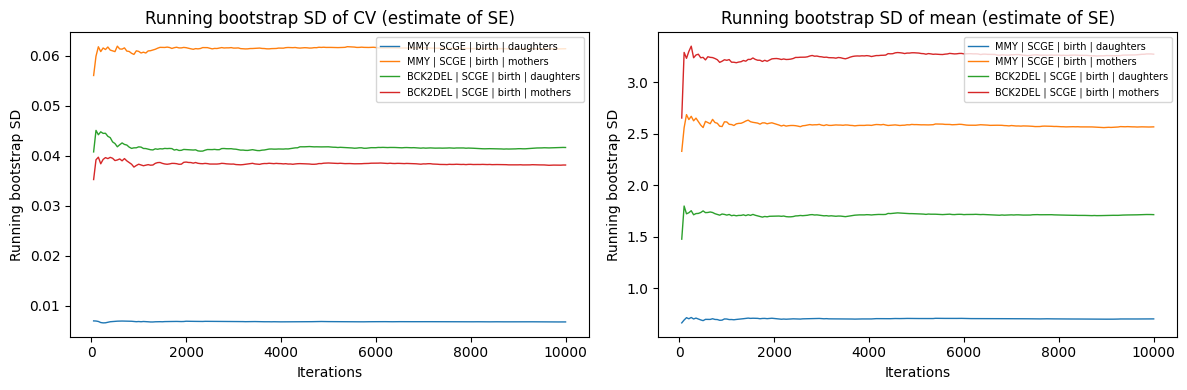

In [8]:
# ── Convergence check: running bootstrap SD (estimate of SE) vs. iterations ──
# Uses the stored bootstrap distributions - no re-running needed.

check_keys     = list(bs_cv_distributions.keys())[:4]   # first 4 groups
check_interval = max(1, n_iterations // 200)             # ~200 plot points
iters          = np.arange(check_interval, n_iterations + 1, check_interval)

fig_conv, axes_conv = plt.subplots(1, 2, figsize=(12, 4), tight_layout=True)
axes_conv[0].set_title("Running bootstrap SD of CV (estimate of SE)")
axes_conv[1].set_title("Running bootstrap SD of mean (estimate of SE)")

for key in check_keys:
    ccp_k, medium_k, strain_k, label_k = key
    cvs_k = bs_cv_distributions[key]
    mns_k = bs_mean_distributions[key]

    se_cv = [np.std(cvs_k[:i]) for i in iters]
    se_mn = [np.std(mns_k[:i]) for i in iters]

    lbl = f"{strain_k} | {medium_k} | {ccp_k} | {label_k}"
    axes_conv[0].plot(iters, se_cv, lw=1, label=lbl)
    axes_conv[1].plot(iters, se_mn, lw=1, label=lbl)

for ax in axes_conv:
    ax.set_xlabel("Iterations")
    ax.set_ylabel("Running bootstrap SD")
    ax.legend(fontsize=7, loc='upper right')

plt.show()

# ***calculate sandard error from sd and n*** 

In [9]:
CV_df['se_daughters'] = (CV_df['sd_daughters'])/(np.sqrt(CV_df['n_daughters']))
CV_df['se_mothers'] = (CV_df['sd_mothers'])/(np.sqrt(CV_df['n_mothers']))
#display(CV_df)

# ***Fig S3 steady-state daughters CV of cell vol at cell-cycle milestones*** 

In [10]:
# ── Build position-level CV and mean DataFrames for significance annotations ──
# Each position = one independent observation; used for CV significance tests.
# cell_vol_df has one row per cell; used for mean-volume significance tests.



pos_records_cv   = []
pos_records_mean = []
cell_records_vol = []

for ccp, (src_df, vol_col) in milestone_dfs.items():
    for medium in src_df['growthmedium'].unique():
        for daughterhood, cell_type in [(1, 'daughters'), (0, 'mothers')]:
            sub = src_df[
                (src_df['growthmedium'] == medium) &
                (src_df['Daughterhood_binary'] == daughterhood) &
                (src_df['is_cell_dead'] == 0) &
                (src_df['complete_phase'] == True)
            ]
            for strain in sub['Strain'].unique():
                strain_sub = sub[sub['Strain'] == strain]
                base = {'growthmedium': medium, 'Strain': strain,
                        'cell_cycle_point': ccp, 'cell_type': cell_type}

                # per-position summaries (for CV tests)
                for pos, vals in strain_sub.groupby('Position')[vol_col]:
                    v = vals.values
                    if len(v) < 2:
                        continue
                    pos_mean = v.mean()
                    pos_cv   = v.std(ddof=1) / pos_mean if pos_mean != 0 else np.nan
                    pos_records_cv.append(  {**base, 'cv':  pos_cv})
                    pos_records_mean.append({**base, 'vol': pos_mean})

                # per-cell values (for mean-volume significance tests)
                for vol in strain_sub[vol_col].dropna().values:
                    cell_records_vol.append({**base, 'vol': vol})

pos_cv_df   = pd.DataFrame(pos_records_cv)
pos_mean_df = pd.DataFrame(pos_records_mean)
cell_vol_df = pd.DataFrame(cell_records_vol)
print(f"pos_cv_df: {len(pos_cv_df)} rows  |  pos_mean_df: {len(pos_mean_df)} rows  |  cell_vol_df: {len(cell_vol_df)} rows")


pos_cv_df: 517 rows  |  pos_mean_df: 517 rows  |  cell_vol_df: 11589 rows


In [11]:
# # ── Normality + pairwise stats via core ──────────────────────────────────────
# # CV: position-level (one CV per position); Mean volume: cell-level (one cell per row)

# comparisons_vs_wt = [
#     ("MMY", "WHI5DEL"),
#     ("MMY", "BCK2DEL"),
#     ("MMY", "WHI5_BCK2_DD"),
#     ("MMY", "CCR4DEL"),
#     ("MMY", "WHI5_CCR4_DD"),
# ]

# strain_labels_stats = {
#     "MMY": "WT", "WHI5DEL": "Δwhi5", "BCK2DEL": "Δbck2",
#     "WHI5_BCK2_DD": "Δwhi5Δbck2", "CCR4DEL": "Δccr4", "WHI5_CCR4_DD": "Δwhi5Δccr4",
# }

# for medium in ['SCD', 'SCGE']:
#     for cell_type in ['daughters', 'mothers']:
#         for value_col, df_src, label in [('cv',  pos_cv_df,   'CV (position-level)'),
#                                           ('vol', cell_vol_df, 'Mean volume (cell-level)')]:
#             sub = df_src[
#                 (df_src['growthmedium'] == medium) &
#                 (df_src['cell_type']    == cell_type)
#             ]
#             # Only keep comparisons where both strains are present
#             valid_comps = [(a, b) for a, b in comparisons_vs_wt
#                            if a in sub['Strain'].values and b in sub['Strain'].values]
#             if not valid_comps:
#                 continue
#             core.run_stats(
#                 sub,
#                 value_cols=value_col,
#                 comparisons=valid_comps,
#                 group_col='Strain',
#                 group_labels=strain_labels_stats,
#                 title=f"{medium} | {cell_type} | {label}",
#             )


95%: [-0.136, -0.007], 99%: [-0.157, 0.013], 99.9%: [-0.183, 0.031]
Pred. p-value: 0.015, stars: *
95%: [-0.257, 0.031], 99%: [-0.294, 0.043], 99.9%: [-0.330, 0.053]
Pred. p-value: 0.055, stars: ns
95%: [-0.078, 0.026], 99%: [-0.096, 0.035], 99.9%: [-0.114, 0.044]
Pred. p-value: 0.055, stars: ns
95%: [-0.232, -0.122], 99%: [-0.246, -0.099], 99.9%: [-0.261, -0.057]
Pred. p-value: 0.0005, stars: ***
95%: [-0.340, -0.097], 99%: [-0.378, -0.070], 99.9%: [-0.409, -0.041]
Pred. p-value: 0.0005, stars: ***
95%: [-0.122, 0.018], 99%: [-0.149, 0.034], 99.9%: [-0.182, 0.051]
Pred. p-value: 0.055, stars: ns
95%: [-0.085, 0.023], 99%: [-0.100, 0.035], 99.9%: [-0.111, 0.046]
Pred. p-value: 0.055, stars: ns
95%: [-0.066, 0.050], 99%: [-0.086, 0.064], 99.9%: [-0.105, 0.074]
Pred. p-value: 0.055, stars: ns
95%: [-0.257, -0.106], 99%: [-0.285, -0.080], 99.9%: [-0.314, -0.053]
Pred. p-value: 0.0005, stars: ***
95%: [-0.250, -0.094], 99%: [-0.273, -0.076], 99.9%: [-0.297, -0.058]
Pred. p-value: 0.0005, s

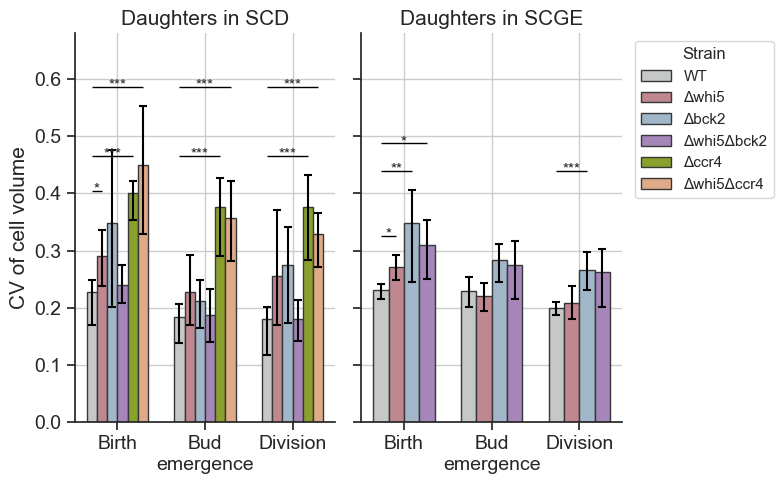

In [12]:
sns.set_context("notebook", rc={"lines.linewidth": 1.5})
sns.set_style("ticks", {'axes.grid': True})
importlib.reload(core)
USE_BOOTSTRAP_SE = True
CV_df.drop((CV_df[((CV_df["strain"] == "CCR4DEL")|
                   (CV_df["strain"] == "WHI5_CCR4_DD")) &
                   (CV_df["growthmedium"] == "SCGE")].index), inplace=True)
cmap = {
    "MMY": "#c6c8c7ff",
    "WHI5DEL": "#bf8890ff",
    "BCK2DEL": "#a2b6c9ff",
    "WHI5_BCK2_DD": "#a686b9ff",
    "CCR4DEL": "#89a02cff",
    "WHI5_CCR4_DD": "#deaa87ff",
}
x_order = ["birth", "bud_emergence", "division"]
hue_order = ["MMY", "WHI5DEL", "BCK2DEL", "WHI5_BCK2_DD", "CCR4DEL", "WHI5_CCR4_DD"]
col_order = ['SCD', 'SCGE']
strain_labels_map = {"MMY": "WT", "WHI5DEL": "Δwhi5", "BCK2DEL": "Δbck2",
                     "WHI5_BCK2_DD": "Δwhi5Δbck2", "CCR4DEL": "Δccr4", "WHI5_CCR4_DD": "Δwhi5Δccr4"}

idx = ['growthmedium', 'strain', 'cell_cycle_point']
if USE_BOOTSTRAP_SE:
    ci_low_lookup = CV_df.set_index(idx)['bs_ci_cv_lower_daughters'].to_dict()
    ci_high_lookup = CV_df.set_index(idx)['bs_ci_cv_upper_daughters'].to_dict()
else:
    se_lookup = (CV_df.set_index(idx)
                      .apply(lambda r: r['se_daughters'] / r['mean_daughters'] if r['mean_daughters'] != 0 else np.nan, axis=1)
                      .to_dict())
val_lookup = CV_df.set_index(idx)['CV_daughters'].to_dict()

# Build long-format DataFrame of bootstrap CV distributions for significance testing.
# Keys in bs_cv_distributions: (ccp, medium, strain, cell_type)
bs_daughters_rows = []
for (ccp, medium, strain, cell_type), cvs in bs_cv_distributions.items():
    if cell_type != 'daughters':
        continue
    for v in cvs:
        bs_daughters_rows.append({'cell_cycle_point': ccp, 'growthmedium': medium,
                                   'Strain': strain, 'cv': v})
bs_daughters_df = pd.DataFrame(bs_daughters_rows)

fig, axes = plt.subplots(1, 2, figsize=(8, 5), sharey=True)
x = np.arange(len(x_order))

for col_idx, medium in enumerate(col_order):
    ax = axes[col_idx]
    actual_hues = [s for s in hue_order if s in CV_df[CV_df['growthmedium'] == medium]['strain'].values]
    n_h = len(actual_hues)
    bar_width = 0.7 / n_h

    for hi, strain in enumerate(actual_hues):
        offsets = x + (hi - n_h / 2 + 0.5) * bar_width
        heights = [val_lookup.get((medium, strain, ccp), np.nan) for ccp in x_order]
        if USE_BOOTSTRAP_SE:
            lower_errors = [max(0.0, h - ci_low_lookup.get((medium, strain, ccp), np.nan)) for h, ccp in zip(heights, x_order)]
            upper_errors = [max(0.0, ci_high_lookup.get((medium, strain, ccp), np.nan) - h) for h, ccp in zip(heights, x_order)]
            errors = np.array([lower_errors, upper_errors])
        else:
            errors = [se_lookup.get((medium, strain, ccp), np.nan) for ccp in x_order]
        ax.bar(offsets, heights, width=bar_width, yerr=errors,
               color=cmap[strain], edgecolor='#363737',
               error_kw=dict(linewidth=1.5, capthick=1.5, color='k', capsize=3),
               label=strain_labels_map[strain])

    ax.set_xticks(x)
    ax.set_xticklabels(["Birth", "Bud\nemergence", "Division"], fontsize=14)
    ax.set_xlabel("", fontsize=15)
    ax.set_ylim(0, 0.68)
    sns.despine(ax=ax)
    core.annotate_significance_hue_vs_ref(
        ax,
        bs_daughters_df[bs_daughters_df['growthmedium'] == medium],
        x_col='cell_cycle_point', y_col='cv', hue_col='Strain',
        x_order=x_order, hue_order=actual_hues, ref_hue='MMY',
        box_width=0.7, show_n=False, star_fontsize=11, other_fontsize=8,
        star_gap=-0.015,
        test="bs",
        suppress_labels={"ns"},
        reserve_suppressed=False
    )
    # for x_val in x_order:
    #     core.run_stats(
    #         bs_daughters_df[(bs_daughters_df['growthmedium'] == medium) & (bs_daughters_df['cell_cycle_point'] == x_val)],
    #         group_col='Strain',value_cols=['cv'], title=f"{medium} - {x_val}"
    #     )

axes[0].set_ylabel("CV of cell volume", fontsize=15)
axes[0].tick_params(axis='y', labelsize=14)
axes[1].set_ylabel("")
axes[0].set_title("Daughters in SCD", fontsize=15)
axes[1].set_title("Daughters in SCGE", fontsize=15)

from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=cmap[s], edgecolor='#363737', label=strain_labels_map[s])
                  for s in hue_order if s in CV_df['strain'].values]
axes[1].legend(handles=legend_handles, title='Strain', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11)

plt.tight_layout()
plt.savefig(r"C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter\new_plots\S3_daughters_CV.svg")
plt.show()


# ***Fig S3 steady-state daughters cell vol at cell-cycle milestones*** 


SCD - birth
Group: '['Strain']'  |  Value: 'vol'


,Strain,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,"(CCR4DEL,)",302,94.4,80.3,1.51,9,Shapiro-Wilk,0.0,False
1,"(BCK2DEL,)",438,85.3,73.1,1.87,5,Shapiro-Wilk,0.0,False
2,"(WHI5_CCR4_DD,)",303,109.9,90.9,1.45,12,Shapiro-Wilk,0.0,False
3,"(WHI5_BCK2_DD,)",584,66.3,58.0,1.06,9,Shapiro-Wilk,0.0,False
4,"(MMY,)",412,65.6,56.1,1.03,4,Shapiro-Wilk,0.0,False
5,"(WHI5DEL,)",488,49.9,43.2,2.00,6,Shapiro-Wilk,0.0,False


,comparison,n_1,n_2,Welch_t_p,t_p,MannWhitneyU_p,tw_sig (p<0.05),t_sig (p<0.05),MWU_sig (p<0.05),Any difference
0,"('CCR4DEL',) vs ('MMY',)",302,412,0.0000,0.0000,0.0000,True,True,True,False
1,"('CCR4DEL',) vs ('BCK2DEL',)",302,438,0.0156,0.0105,0.2816,True,True,False,True
2,"('CCR4DEL',) vs ('WHI5DEL',)",302,488,0.0000,0.0000,0.0000,True,True,True,False
3,"('CCR4DEL',) vs ('WHI5_BCK2_DD',)",302,584,0.0000,0.0000,0.0000,True,True,True,False
4,"('CCR4DEL',) vs ('WHI5_CCR4_DD',)",302,303,0.0013,0.0013,0.0005,True,True,True,False
5,"('MMY',) vs ('BCK2DEL',)",412,438,0.0000,0.0000,0.0000,True,True,True,False
6,"('MMY',) vs ('WHI5DEL',)",412,488,0.0000,0.0000,0.0000,True,True,True,False
7,"('MMY',) vs ('WHI5_BCK2_DD',)",412,584,0.6984,0.6959,0.2755,False,False,False,False
8,"('MMY',) vs ('WHI5_CCR4_DD',)",412,303,0.0000,0.0000,0.0000,True,True,True,False
9,"('BCK2DEL',) vs ('WHI5DEL',)",438,488,0.0000,0.0000,0.0000,True,True,True,False



SCD - bud_emergence
Group: '['Strain']'  |  Value: 'vol'


,Strain,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,"(CCR4DEL,)",302,94.4,80.3,1.51,9,Shapiro-Wilk,0.0,False
1,"(BCK2DEL,)",438,85.3,73.1,1.87,5,Shapiro-Wilk,0.0,False
2,"(WHI5_CCR4_DD,)",303,109.9,90.9,1.45,12,Shapiro-Wilk,0.0,False
3,"(WHI5_BCK2_DD,)",584,66.3,58.0,1.06,9,Shapiro-Wilk,0.0,False
4,"(MMY,)",412,65.6,56.1,1.03,4,Shapiro-Wilk,0.0,False
5,"(WHI5DEL,)",488,49.9,43.2,2.00,6,Shapiro-Wilk,0.0,False


...

,Strain,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,"(CCR4DEL,)",147,152.5,128.9,1.23,3,Shapiro-Wilk,1.395000e-07,False
1,"(BCK2DEL,)",568,82.1,71.4,1.02,8,Shapiro-Wilk,0.000000e+00,False
2,"(WHI5_CCR4_DD,)",90,112.9,92.1,1.00,2,Shapiro-Wilk,8.078530e-05,False
3,"(WHI5_BCK2_DD,)",566,56.1,48.7,1.23,15,Shapiro-Wilk,0.000000e+00,False
4,"(MMY,)",744,51.0,43.6,1.00,8,Shapiro-Wilk,0.000000e+00,False
5,"(WHI5DEL,)",522,42.5,36.7,0.99,12,Shapiro-Wilk,0.000000e+00,False


,comparison,n_1,n_2,Welch_t_p,t_p,MannWhitneyU_p,tw_sig (p<0.05),t_sig (p<0.05),MWU_sig (p<0.05),Any difference
0,"('MMY',) vs ('BCK2DEL',)",744,568,0.0000,0.0000,0.0000,True,True,True,False
1,"('MMY',) vs ('CCR4DEL',)",744,147,0.0000,0.0000,0.0000,True,True,True,False
2,"('MMY',) vs ('WHI5DEL',)",744,522,0.0000,0.0000,0.0000,True,True,True,False
3,"('MMY',) vs ('WHI5_BCK2_DD',)",744,566,0.0004,0.0003,0.0003,True,True,True,False
4,"('MMY',) vs ('WHI5_CCR4_DD',)",744,90,0.0000,0.0000,0.0000,True,True,True,False
5,"('BCK2DEL',) vs ('CCR4DEL',)",568,147,0.0000,0.0000,0.0000,True,True,True,False
6,"('BCK2DEL',) vs ('WHI5DEL',)",568,522,0.0000,0.0000,0.0000,True,True,True,False
7,"('BCK2DEL',) vs ('WHI5_BCK2_DD',)",568,566,0.0000,0.0000,0.0000,True,True,True,False
8,"('BCK2DEL',) vs ('WHI5_CCR4_DD',)",568,90,0.0001,0.0000,0.0003,True,True,True,False
9,"('CCR4DEL',) vs ('WHI5DEL',)",147,522,0.0000,0.0000,0.0000,True,True,True,False



SCGE - division
Group: '['Strain']'  |  Value: 'vol'


,Strain,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,"(CCR4DEL,)",147,152.5,128.9,1.23,3,Shapiro-Wilk,1.395000e-07,False
1,"(BCK2DEL,)",568,82.1,71.4,1.02,8,Shapiro-Wilk,0.000000e+00,False
2,"(WHI5_CCR4_DD,)",90,112.9,92.1,1.00,2,Shapiro-Wilk,8.078530e-05,False
3,"(WHI5_BCK2_DD,)",566,56.1,48.7,1.23,15,Shapiro-Wilk,0.000000e+00,False
4,"(MMY,)",744,51.0,43.6,1.00,8,Shapiro-Wilk,0.000000e+00,False
5,"(WHI5DEL,)",522,42.5,36.7,0.99,12,Shapiro-Wilk,0.000000e+00,False


,comparison,n_1,n_2,Welch_t_p,t_p,MannWhitneyU_p,tw_sig (p<0.05),t_sig (p<0.05),MWU_sig (p<0.05),Any difference
0,"('MMY',) vs ('BCK2DEL',)",744,568,0.0000,0.0000,0.0000,True,True,True,False
1,"('MMY',) vs ('CCR4DEL',)",744,147,0.0000,0.0000,0.0000,True,True,True,False
2,"('MMY',) vs ('WHI5DEL',)",744,522,0.0000,0.0000,0.0000,True,True,True,False
3,"('MMY',) vs ('WHI5_BCK2_DD',)",744,566,0.0004,0.0003,0.0003,True,True,True,False
4,"('MMY',) vs ('WHI5_CCR4_DD',)",744,90,0.0000,0.0000,0.0000,True,True,True,False
5,"('BCK2DEL',) vs ('CCR4DEL',)",568,147,0.0000,0.0000,0.0000,True,True,True,False
6,"('BCK2DEL',) vs ('WHI5DEL',)",568,522,0.0000,0.0000,0.0000,True,True,True,False
7,"('BCK2DEL',) vs ('WHI5_BCK2_DD',)",568,566,0.0000,0.0000,0.0000,True,True,True,False
8,"('BCK2DEL',) vs ('WHI5_CCR4_DD',)",568,90,0.0001,0.0000,0.0003,True,True,True,False
9,"('CCR4DEL',) vs ('WHI5DEL',)",147,522,0.0000,0.0000,0.0000,True,True,True,False


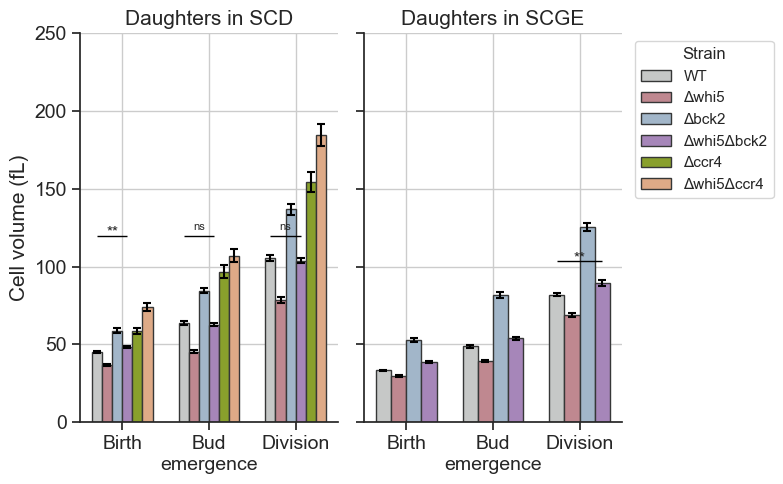

In [23]:
sns.set_context("notebook", rc={"lines.linewidth": 1.5})
sns.set_style("ticks", {'axes.grid': True})
importlib.reload(core)
USE_BOOTSTRAP_SE = False

CV_df.drop((CV_df[((CV_df["strain"] == "CCR4DEL")|
                   (CV_df["strain"] == "WHI5_CCR4_DD")) &
                   (CV_df["growthmedium"] == "SCGE")].index), inplace=True)

cmap = {
    "MMY": "#c6c8c7ff",
    "WHI5DEL": "#bf8890ff",
    "BCK2DEL": "#a2b6c9ff",
    "WHI5_BCK2_DD": "#a686b9ff",
    "CCR4DEL": "#89a02cff",
    "WHI5_CCR4_DD": "#deaa87ff",
}
x_order = ["birth", "bud_emergence", "division"]
hue_order = ["MMY", "WHI5DEL", "BCK2DEL", "WHI5_BCK2_DD", "CCR4DEL", "WHI5_CCR4_DD"]
col_order = ['SCD', 'SCGE']
strain_labels_map = {"MMY": "WT", "WHI5DEL": "Δwhi5", "BCK2DEL": "Δbck2",
                     "WHI5_BCK2_DD": "Δwhi5Δbck2", "CCR4DEL": "Δccr4", "WHI5_CCR4_DD": "Δwhi5Δccr4"}

idx = ['growthmedium', 'strain', 'cell_cycle_point']
if USE_BOOTSTRAP_SE:
    se_lookup = CV_df.set_index(idx)['bs_se_mean_daughters'].to_dict()
else:
    se_lookup = CV_df.set_index(idx)['se_daughters'].to_dict()
val_lookup = CV_df.set_index(idx)['mean_daughters'].to_dict()

fig, axes = plt.subplots(1, 2, figsize=(8, 5), sharey=True)
x = np.arange(len(x_order))

for col_idx, medium in enumerate(col_order):
    ax = axes[col_idx]
    actual_hues = [s for s in hue_order if s in CV_df[CV_df['growthmedium'] == medium]['strain'].values]
    n_h = len(actual_hues)
    bar_width = 0.7 / n_h

    for hi, strain in enumerate(actual_hues):
        offsets = x + (hi - n_h / 2 + 0.5) * bar_width
        heights = [val_lookup.get((medium, strain, ccp), np.nan) for ccp in x_order]
        errors  = [se_lookup.get((medium, strain, ccp), np.nan) for ccp in x_order]
        ax.bar(offsets, heights, width=bar_width, yerr=errors,
               color=cmap[strain], edgecolor='#363737',
               error_kw=dict(linewidth=1.5, capthick=1.5, color='k', capsize=3),
               label=strain_labels_map[strain])

    ax.set_xticks(x)
    ax.set_xticklabels(["Birth", "Bud\nemergence", "Division"], fontsize=14)
    ax.set_xlabel("", fontsize=15)
    ax.set_ylim(0, 250)
    sns.despine(ax=ax)
    core.annotate_significance_hue_vs_ref(
        ax,
        cell_vol_df[(cell_vol_df['growthmedium'] == medium) & (cell_vol_df['cell_type'] == 'daughters')],
        x_col='cell_cycle_point', y_col='vol', hue_col='Strain',
        x_order=x_order, hue_order=actual_hues, ref_hue='MMY', star_gap=-0.01,
        box_width=0.7, show_n=False, star_fontsize=11, other_fontsize=8,
        test="mwu", suppress_labels={"***"},
        reserve_suppressed=False
    )
    for x_val in x_order:
        core.run_stats(
            cell_vol_df[(cell_vol_df['growthmedium'] == medium) & (cell_vol_df['cell_type'] == 'daughters')],
            group_col='Strain',value_cols=['vol'], title=f"{medium} - {x_val}"
        )
    

axes[0].set_ylabel("Cell volume (fL)", fontsize=15)
axes[0].tick_params(axis='y', labelsize=14)
axes[1].set_ylabel("")
axes[0].set_title("Daughters in SCD", fontsize=15)
axes[1].set_title("Daughters in SCGE", fontsize=15)

from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=cmap[s], edgecolor='#363737', label=strain_labels_map[s])
                  for s in hue_order if s in CV_df['strain'].values]
axes[1].legend(handles=legend_handles, title='Strain', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11)

plt.tight_layout()
plt.savefig(r"C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter\new_plots\S3_daughters.svg")
plt.show()


# ***Fig S3 steady-state mothers CV of cell vol at cell-cycle milestones*** 

95%: [-0.192, -0.012], 99%: [-0.213, 0.009], 99.9%: [-0.244, 0.043]
Pred. p-value: 0.015, stars: *
95%: [-0.119, 0.039], 99%: [-0.144, 0.058], 99.9%: [-0.166, 0.076]
Pred. p-value: 0.055, stars: ns
95%: [-0.092, 0.012], 99%: [-0.114, 0.029], 99.9%: [-0.126, 0.047]
Pred. p-value: 0.055, stars: ns
95%: [-0.361, -0.114], 99%: [-0.402, -0.081], 99.9%: [-0.456, -0.057]
Pred. p-value: 0.0005, stars: ***
95%: [-0.406, -0.210], 99%: [-0.447, -0.158], 99.9%: [-0.490, -0.082]
Pred. p-value: 0.0005, stars: ***
95%: [-0.214, 0.016], 99%: [-0.240, 0.035], 99.9%: [-0.273, 0.063]
Pred. p-value: 0.055, stars: ns
95%: [-0.089, 0.056], 99%: [-0.111, 0.069], 99.9%: [-0.142, 0.085]
Pred. p-value: 0.055, stars: ns
95%: [-0.084, 0.024], 99%: [-0.106, 0.042], 99.9%: [-0.128, 0.063]
Pred. p-value: 0.055, stars: ns
95%: [-0.390, -0.094], 99%: [-0.435, -0.066], 99.9%: [-0.479, -0.044]
Pred. p-value: 0.0005, stars: ***
95%: [-0.365, -0.157], 99%: [-0.405, -0.100], 99.9%: [-0.454, -0.051]
Pred. p-value: 0.0005, s

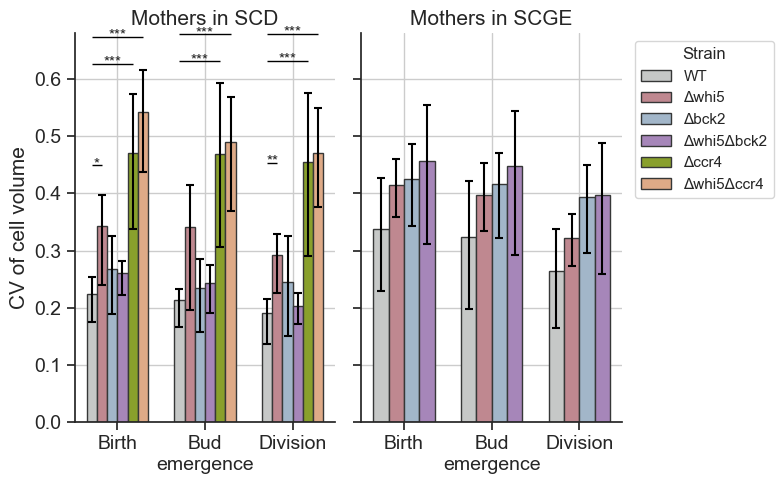

In [14]:
sns.set_context("notebook", rc={"lines.linewidth": 1.5})
sns.set_style("ticks", {'axes.grid': True})
importlib.reload(core)
USE_BOOTSTRAP_SE = True
CV_df.drop((CV_df[((CV_df["strain"] == "CCR4DEL")|
                   (CV_df["strain"] == "WHI5_CCR4_DD")) &
                   (CV_df["growthmedium"] == "SCGE")].index), inplace=True)

cmap = {
    "MMY": "#c6c8c7ff",
    "WHI5DEL": "#bf8890ff",
    "BCK2DEL": "#a2b6c9ff",
    "WHI5_BCK2_DD": "#a686b9ff",
    "CCR4DEL": "#89a02cff",
    "WHI5_CCR4_DD": "#deaa87ff",
}
x_order = ["birth", "bud_emergence", "division"]
hue_order = ["MMY", "WHI5DEL", "BCK2DEL", "WHI5_BCK2_DD", "CCR4DEL", "WHI5_CCR4_DD"]
col_order = ['SCD', 'SCGE']
strain_labels_map = {"MMY": "WT", "WHI5DEL": "Δwhi5", "BCK2DEL": "Δbck2",
                     "WHI5_BCK2_DD": "Δwhi5Δbck2", "CCR4DEL": "Δccr4", "WHI5_CCR4_DD": "Δwhi5Δccr4"}

idx = ['growthmedium', 'strain', 'cell_cycle_point']
if USE_BOOTSTRAP_SE:
    ci_low_lookup = CV_df.set_index(idx)['bs_ci_cv_lower_mothers'].to_dict()
    ci_high_lookup = CV_df.set_index(idx)['bs_ci_cv_upper_mothers'].to_dict()
else:
    se_lookup = (CV_df.set_index(idx)
                      .apply(lambda r: r['se_mothers'] / r['mean_mothers'] if r['mean_mothers'] != 0 else np.nan, axis=1)
                      .to_dict())
val_lookup = CV_df.set_index(idx)['CV_mothers'].to_dict()

# Build long-format DataFrame of bootstrap CV distributions for significance testing.
# Keys in bs_cv_distributions: (ccp, medium, strain, cell_type)
bs_mothers_rows = []
for (ccp, medium, strain, cell_type), cvs in bs_cv_distributions.items():
    if cell_type != 'mothers':
        continue
    for v in cvs:
        bs_mothers_rows.append({'cell_cycle_point': ccp, 'growthmedium': medium,
                                 'Strain': strain, 'cv': v})
bs_mothers_df = pd.DataFrame(bs_mothers_rows)

fig, axes = plt.subplots(1, 2, figsize=(8, 5), sharey=True)
x = np.arange(len(x_order))

for col_idx, medium in enumerate(col_order):
    ax = axes[col_idx]
    actual_hues = [s for s in hue_order if s in CV_df[CV_df['growthmedium'] == medium]['strain'].values]
    n_h = len(actual_hues)
    bar_width = 0.7 / n_h

    for hi, strain in enumerate(actual_hues):
        offsets = x + (hi - n_h / 2 + 0.5) * bar_width
        heights = [val_lookup.get((medium, strain, ccp), np.nan) for ccp in x_order]
        if USE_BOOTSTRAP_SE:
            lower_errors = [max(0.0, h - ci_low_lookup.get((medium, strain, ccp), np.nan)) for h, ccp in zip(heights, x_order)]
            upper_errors = [max(0.0, ci_high_lookup.get((medium, strain, ccp), np.nan) - h) for h, ccp in zip(heights, x_order)]
            errors = np.array([lower_errors, upper_errors])
        else:
            errors = [se_lookup.get((medium, strain, ccp), np.nan) for ccp in x_order]
        ax.bar(offsets, heights, width=bar_width, yerr=errors,
               color=cmap[strain], edgecolor='#363737',
               error_kw=dict(linewidth=1.5, capthick=1.5, color='k', capsize=3),
               label=strain_labels_map[strain])

    ax.set_xticks(x)
    ax.set_xticklabels(["Birth", "Bud\nemergence", "Division"], fontsize=14)
    ax.set_xlabel("", fontsize=15)
    ax.set_ylim(0, 0.68)
    sns.despine(ax=ax)
    core.annotate_significance_hue_vs_ref(
        ax,
        bs_mothers_df[bs_mothers_df['growthmedium'] == medium],
        x_col='cell_cycle_point', y_col='cv', hue_col='Strain',
        x_order=x_order, hue_order=actual_hues, ref_hue='MMY', star_gap=-0.013,
        box_width=0.7, show_n=False, star_fontsize=11, other_fontsize=8,
        test="bs", suppress_labels={"ns"},
        reserve_suppressed=True
    )

axes[0].set_ylabel("CV of cell volume", fontsize=15)
axes[0].tick_params(axis='y', labelsize=14)
axes[1].set_ylabel("")
axes[0].set_title("Mothers in SCD", fontsize=15)
axes[1].set_title("Mothers in SCGE", fontsize=15)

from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=cmap[s], edgecolor='#363737', label=strain_labels_map[s])
                  for s in hue_order if s in CV_df['strain'].values]
axes[1].legend(handles=legend_handles, title='Strain', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11)

plt.tight_layout()
plt.savefig(r"C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter\new_plots\S3_mothers_cv.svg")
plt.show()


# ***Fig S3 steady-state mothers cell vol at cell-cycle milestones*** 


SCD - birth
Group: '['Strain']'  |  Value: 'vol'


,Strain,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,"(CCR4DEL,)",490,156.5,138.7,2.25,17,Shapiro-Wilk,0.0,False
1,"(BCK2DEL,)",592,120.4,110.2,1.87,12,Shapiro-Wilk,0.0,False
2,"(WHI5_CCR4_DD,)",523,177.0,153.5,1.81,33,Shapiro-Wilk,0.0,False
3,"(WHI5_BCK2_DD,)",693,91.5,81.8,1.05,12,Shapiro-Wilk,0.0,False
4,"(MMY,)",564,87.5,79.3,1.17,10,Shapiro-Wilk,0.0,False
5,"(WHI5DEL,)",566,69.7,62.2,1.92,22,Shapiro-Wilk,0.0,False


,comparison,n_1,n_2,Welch_t_p,t_p,MannWhitneyU_p,tw_sig (p<0.05),t_sig (p<0.05),MWU_sig (p<0.05),Any difference
0,"('CCR4DEL',) vs ('MMY',)",490,564,0.0000,0.0000,0.0000,True,True,True,False
1,"('CCR4DEL',) vs ('BCK2DEL',)",490,592,0.0000,0.0000,0.0000,True,True,True,False
2,"('CCR4DEL',) vs ('WHI5DEL',)",490,566,0.0000,0.0000,0.0000,True,True,True,False
3,"('CCR4DEL',) vs ('WHI5_BCK2_DD',)",490,693,0.0000,0.0000,0.0000,True,True,True,False
4,"('CCR4DEL',) vs ('WHI5_CCR4_DD',)",490,523,0.0002,0.0002,0.0005,True,True,True,False
5,"('MMY',) vs ('BCK2DEL',)",564,592,0.0000,0.0000,0.0000,True,True,True,False
6,"('MMY',) vs ('WHI5DEL',)",564,566,0.0000,0.0000,0.0000,True,True,True,False
7,"('MMY',) vs ('WHI5_BCK2_DD',)",564,693,0.0138,0.0150,0.0322,True,True,True,False
8,"('MMY',) vs ('WHI5_CCR4_DD',)",564,523,0.0000,0.0000,0.0000,True,True,True,False
9,"('BCK2DEL',) vs ('WHI5DEL',)",592,566,0.0000,0.0000,0.0000,True,True,True,False



SCD - bud_emergence
Group: '['Strain']'  |  Value: 'vol'


,Strain,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,"(CCR4DEL,)",490,156.5,138.7,2.25,17,Shapiro-Wilk,0.0,False
1,"(BCK2DEL,)",592,120.4,110.2,1.87,12,Shapiro-Wilk,0.0,False
2,"(WHI5_CCR4_DD,)",523,177.0,153.5,1.81,33,Shapiro-Wilk,0.0,False
3,"(WHI5_BCK2_DD,)",693,91.5,81.8,1.05,12,Shapiro-Wilk,0.0,False
4,"(MMY,)",564,87.5,79.3,1.17,10,Shapiro-Wilk,0.0,False
5,"(WHI5DEL,)",566,69.7,62.2,1.92,22,Shapiro-Wilk,0.0,False


...

,Strain,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,"(CCR4DEL,)",145,212.6,197.0,1.19,4,Shapiro-Wilk,0.000002,False
1,"(BCK2DEL,)",651,128.7,113.5,2.16,45,Shapiro-Wilk,0.000000,False
2,"(WHI5_CCR4_DD,)",85,148.2,141.4,1.07,3,Shapiro-Wilk,0.000187,False
3,"(WHI5_BCK2_DD,)",654,85.9,77.2,2.31,34,Shapiro-Wilk,0.000000,False
4,"(MMY,)",876,72.9,67.3,2.13,23,Shapiro-Wilk,0.000000,False
5,"(WHI5DEL,)",586,64.6,57.5,1.43,31,Shapiro-Wilk,0.000000,False


,comparison,n_1,n_2,Welch_t_p,t_p,MannWhitneyU_p,tw_sig (p<0.05),t_sig (p<0.05),MWU_sig (p<0.05),Any difference
0,"('MMY',) vs ('BCK2DEL',)",876,651,0.0000,0.0000,0.000,True,True,True,False
1,"('MMY',) vs ('CCR4DEL',)",876,145,0.0000,0.0000,0.000,True,True,True,False
2,"('MMY',) vs ('WHI5DEL',)",876,586,0.0000,0.0000,0.000,True,True,True,False
3,"('MMY',) vs ('WHI5_BCK2_DD',)",876,654,0.0000,0.0000,0.000,True,True,True,False
4,"('MMY',) vs ('WHI5_CCR4_DD',)",876,85,0.0000,0.0000,0.000,True,True,True,False
5,"('BCK2DEL',) vs ('CCR4DEL',)",651,145,0.0000,0.0000,0.000,True,True,True,False
6,"('BCK2DEL',) vs ('WHI5DEL',)",651,586,0.0000,0.0000,0.000,True,True,True,False
7,"('BCK2DEL',) vs ('WHI5_BCK2_DD',)",651,654,0.0000,0.0000,0.000,True,True,True,False
8,"('BCK2DEL',) vs ('WHI5_CCR4_DD',)",651,85,0.0076,0.0044,0.001,True,True,True,False
9,"('CCR4DEL',) vs ('WHI5DEL',)",145,586,0.0000,0.0000,0.000,True,True,True,False



SCGE - division
Group: '['Strain']'  |  Value: 'vol'


,Strain,n,mean,median,skewness,n_outliers (IQR),normality_test,normality_p,normal (p>0.05)
0,"(CCR4DEL,)",145,212.6,197.0,1.19,4,Shapiro-Wilk,0.000002,False
1,"(BCK2DEL,)",651,128.7,113.5,2.16,45,Shapiro-Wilk,0.000000,False
2,"(WHI5_CCR4_DD,)",85,148.2,141.4,1.07,3,Shapiro-Wilk,0.000187,False
3,"(WHI5_BCK2_DD,)",654,85.9,77.2,2.31,34,Shapiro-Wilk,0.000000,False
4,"(MMY,)",876,72.9,67.3,2.13,23,Shapiro-Wilk,0.000000,False
5,"(WHI5DEL,)",586,64.6,57.5,1.43,31,Shapiro-Wilk,0.000000,False


,comparison,n_1,n_2,Welch_t_p,t_p,MannWhitneyU_p,tw_sig (p<0.05),t_sig (p<0.05),MWU_sig (p<0.05),Any difference
0,"('MMY',) vs ('BCK2DEL',)",876,651,0.0000,0.0000,0.000,True,True,True,False
1,"('MMY',) vs ('CCR4DEL',)",876,145,0.0000,0.0000,0.000,True,True,True,False
2,"('MMY',) vs ('WHI5DEL',)",876,586,0.0000,0.0000,0.000,True,True,True,False
3,"('MMY',) vs ('WHI5_BCK2_DD',)",876,654,0.0000,0.0000,0.000,True,True,True,False
4,"('MMY',) vs ('WHI5_CCR4_DD',)",876,85,0.0000,0.0000,0.000,True,True,True,False
5,"('BCK2DEL',) vs ('CCR4DEL',)",651,145,0.0000,0.0000,0.000,True,True,True,False
6,"('BCK2DEL',) vs ('WHI5DEL',)",651,586,0.0000,0.0000,0.000,True,True,True,False
7,"('BCK2DEL',) vs ('WHI5_BCK2_DD',)",651,654,0.0000,0.0000,0.000,True,True,True,False
8,"('BCK2DEL',) vs ('WHI5_CCR4_DD',)",651,85,0.0076,0.0044,0.001,True,True,True,False
9,"('CCR4DEL',) vs ('WHI5DEL',)",145,586,0.0000,0.0000,0.000,True,True,True,False


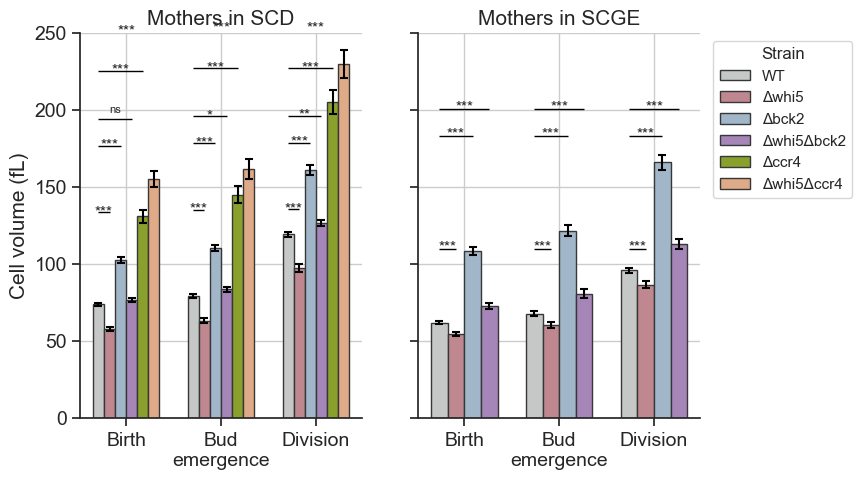

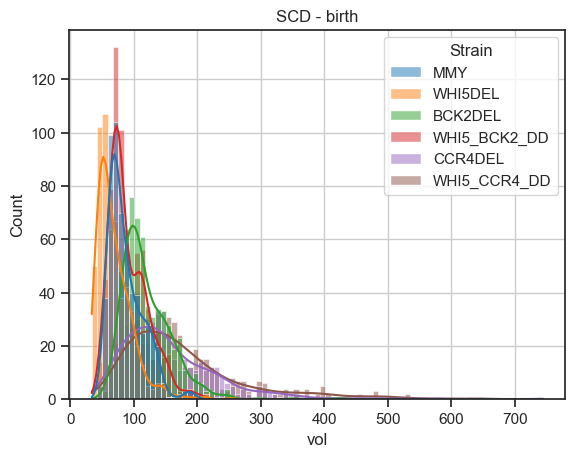

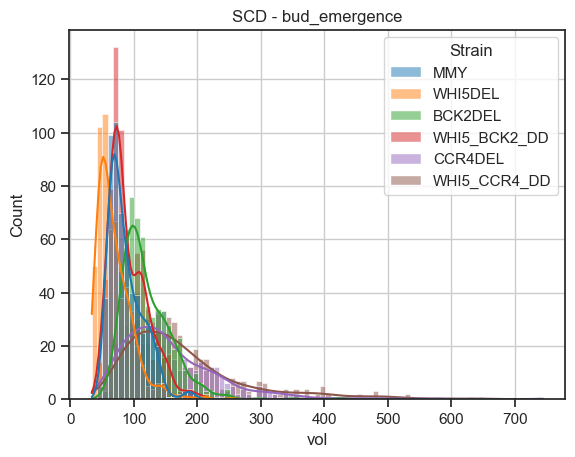

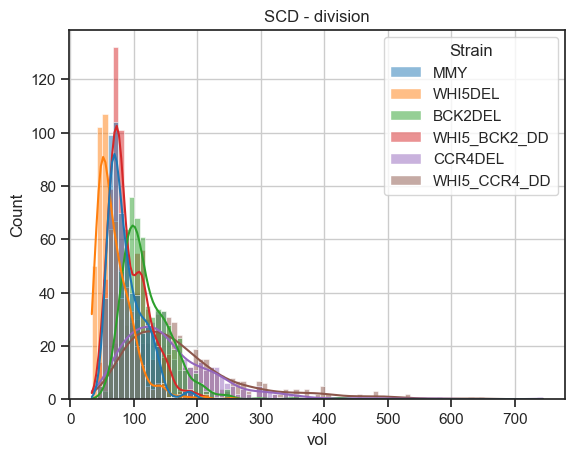

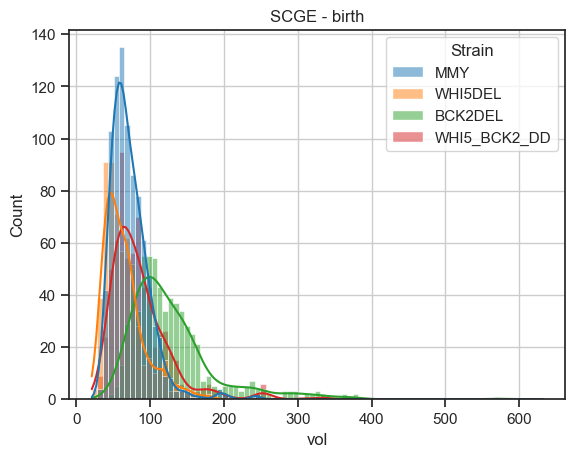

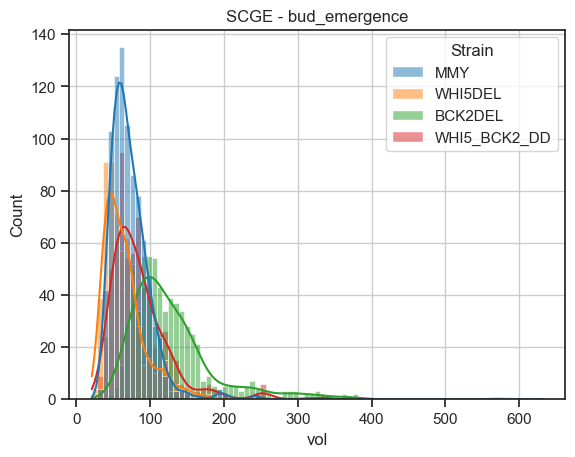

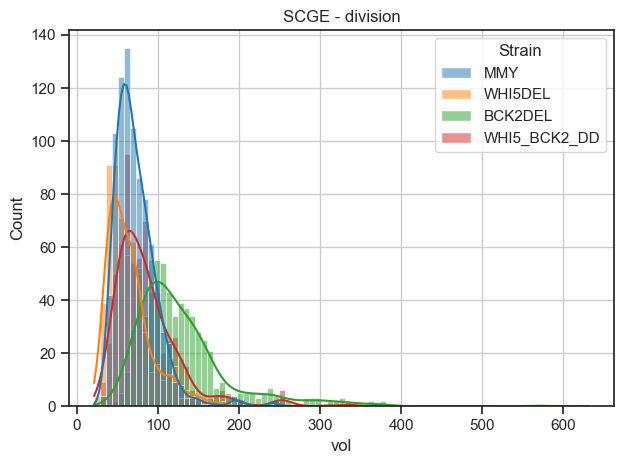

In [27]:
sns.set_context("notebook", rc={"lines.linewidth": 1.5})
sns.set_style("ticks", {'axes.grid': True})
importlib.reload(core)
USE_BOOTSTRAP_SE = False
CV_df.drop((CV_df[((CV_df["strain"] == "CCR4DEL")|
                   (CV_df["strain"] == "WHI5_CCR4_DD")) &
                   (CV_df["growthmedium"] == "SCGE")].index), inplace=True)

cmap = {
    "MMY": "#c6c8c7ff",
    "WHI5DEL": "#bf8890ff",
    "BCK2DEL": "#a2b6c9ff",
    "WHI5_BCK2_DD": "#a686b9ff",
    "CCR4DEL": "#89a02cff",
    "WHI5_CCR4_DD": "#deaa87ff",
}
x_order = ["birth", "bud_emergence", "division"]
hue_order = ["MMY", "WHI5DEL", "BCK2DEL", "WHI5_BCK2_DD", "CCR4DEL", "WHI5_CCR4_DD"]
col_order = ['SCD', 'SCGE']
strain_labels_map = {"MMY": "WT", "WHI5DEL": "Δwhi5", "BCK2DEL": "Δbck2",
                     "WHI5_BCK2_DD": "Δwhi5Δbck2", "CCR4DEL": "Δccr4", "WHI5_CCR4_DD": "Δwhi5Δccr4"}

idx = ['growthmedium', 'strain', 'cell_cycle_point']
if USE_BOOTSTRAP_SE:
    se_lookup = CV_df.set_index(idx)['bs_se_mean_mothers'].to_dict()
else:
    se_lookup = CV_df.set_index(idx)['se_mothers'].to_dict()
val_lookup = CV_df.set_index(idx)['mean_mothers'].to_dict()

fig, axes = plt.subplots(1, 2, figsize=(8, 5), sharey=True)
x = np.arange(len(x_order))

for col_idx, medium in enumerate(col_order):
    ax = axes[col_idx]
    actual_hues = [s for s in hue_order if s in CV_df[CV_df['growthmedium'] == medium]['strain'].values]
    n_h = len(actual_hues)
    bar_width = 0.7 / n_h

    for hi, strain in enumerate(actual_hues):
        offsets = x + (hi - n_h / 2 + 0.5) * bar_width
        heights = [val_lookup.get((medium, strain, ccp), np.nan) for ccp in x_order]
        errors  = [se_lookup.get((medium, strain, ccp), np.nan) for ccp in x_order]
        ax.bar(offsets, heights, width=bar_width, yerr=errors,
               color=cmap[strain], edgecolor='#363737',
               error_kw=dict(linewidth=1.5, capthick=1.5, color='k', capsize=3),
               label=strain_labels_map[strain])

    ax.set_xticks(x)
    ax.set_xticklabels(["Birth", "Bud\nemergence", "Division"], fontsize=14)
    ax.set_xlabel("", fontsize=15)
    ax.set_ylim(0, 250)
    sns.despine(ax=ax)
    core.annotate_significance_hue_vs_ref(
        ax,
        cell_vol_df[(cell_vol_df['growthmedium'] == medium) & (cell_vol_df['cell_type'] == 'mothers')],
        x_col='cell_cycle_point', y_col='vol', hue_col='Strain',
        x_order=x_order, hue_order=actual_hues, ref_hue='MMY', star_gap=-0.015,
        box_width=0.7, show_n=False, star_fontsize=11, other_fontsize=8,
        test="mwu", #suppress_labels={"***"},
        reserve_suppressed=False
    )
    for x_val in x_order:
        core.run_stats(
            cell_vol_df[(cell_vol_df['growthmedium'] == medium) & (cell_vol_df['cell_type'] == 'mothers')],
            group_col='Strain',value_cols=['vol'], title=f"{medium} - {x_val}"
        )
        
    # plot cell volume for mothers
    for x_val in x_order:
        plt_1 = plt.figure()
        ax_1 = plt_1.add_subplot(111)
        sns.histplot(
            data=cell_vol_df[(cell_vol_df['growthmedium'] == medium) & (cell_vol_df['cell_type'] == 'mothers')],
            x='vol', hue='Strain', hue_order=actual_hues, ax=ax_1, kde=True
        )
        # add x at mean
        ax_1.set_title(f"{medium} - {x_val}")

axes[0].set_ylabel("Cell volume (fL)", fontsize=15)
axes[0].tick_params(axis='y', labelsize=14)
axes[1].set_ylabel("")
axes[0].set_title("Mothers in SCD", fontsize=15)
axes[1].set_title("Mothers in SCGE", fontsize=15)

from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=cmap[s], edgecolor='#363737', label=strain_labels_map[s])
                  for s in hue_order if s in CV_df['strain'].values]
axes[1].legend(handles=legend_handles, title='Strain', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11)

plt.tight_layout()
plt.savefig(r"C:\Users\timon\OneDrive\Helmholtz\Scripts\Yagya_jupyter\new_plots\S3_mothers.svg")
plt.show()


In [16]:
# import sys, os
# sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..')))
# import importlib
# import core
# importlib.reload(core)

# comparisons = [
#     ("MMY", "WHI5DEL"),
#     ("MMY", "BCK2DEL"),
#     ("MMY", "WHI5_BCK2_DD"),
#     ("MMY", "CCR4DEL"),
#     ("MMY", "WHI5_CCR4_DD"),
# ]

# strain_labels = {
#     "MMY": "WT",
#     "WHI5DEL": "Δwhi5",
#     "BCK2DEL": "Δbck2",
#     "WHI5_BCK2_DD": "Δwhi5Δbck2",
#     "CCR4DEL": "Δccr4",
#     "WHI5_CCR4_DD": "Δwhi5Δccr4",
# }

# for medium in ['SCD', 'SCGE']:
#     for ccp, (src_df, vol_col) in milestone_dfs.items():
#         for daughterhood, label in [(1, 'daughters'), (0, 'mothers')]:
#             sub = src_df[
#                 (src_df['growthmedium'] == medium) &
#                 (src_df['Daughterhood_binary'] == daughterhood) &
#                 (src_df['is_cell_dead'] == 0) &
#                 (src_df['complete_phase'] == True)
#             ].copy()

#             if USE_BOOTSTRAP_SE:
#                 # Use position-level means: each position is one independent observation
#                 sub = sub.groupby(['Position', 'Strain'])[vol_col].mean().reset_index()
#                 sub = sub.rename(columns={vol_col: 'vol'})
#             else:
#                 sub = sub.rename(columns={vol_col: 'vol'})

#             core.run_stats(
#                 sub,
#                 value_cols=['vol'],
#                 comparisons=comparisons,
#                 group_col='Strain',
#                 group_labels=strain_labels,
#                 title=f"{medium} | {ccp} | {label} ({'position means' if USE_BOOTSTRAP_SE else 'cell level'})",
#             )


In [17]:
# # Significance tests for CV using bootstrap permutation
# # Reuses bs_cv_distributions computed in the bootstrap cell — no re-running needed.

# comparisons = [
#     ("MMY", "WHI5DEL"),
#     ("MMY", "BCK2DEL"),
#     ("MMY", "WHI5_BCK2_DD"),
#     ("MMY", "CCR4DEL"),
#     ("MMY", "WHI5_CCR4_DD"),
# ]

# strain_labels = {
#     "MMY": "WT",
#     "WHI5DEL": "Δwhi5",
#     "BCK2DEL": "Δbck2",
#     "WHI5_BCK2_DD": "Δwhi5Δbck2",
#     "CCR4DEL": "Δccr4",
#     "WHI5_CCR4_DD": "Δwhi5Δccr4",
# }

# rng_perm = np.random.default_rng(seed)

# for medium in ['SCD', 'SCGE']:
#     for ccp, (src_df, vol_col) in milestone_dfs.items():
#         for daughterhood, label in [(1, 'daughters'), (0, 'mothers')]:
#             print("\n" + "=" * 80)
#             print(f"{medium} | {ccp} | {label}  —  CV bootstrap permutation test")

#             # Summary table (observed CV per strain)
#             all_strains = list(dict.fromkeys(s for pair in comparisons for s in pair))
#             summary_rows = []
#             for strain in all_strains:
#                 bs_cvs = bs_cv_distributions.get((ccp, medium, strain, label))
#                 if bs_cvs is None:
#                     continue
#                 sub = src_df[
#                     (src_df['growthmedium'] == medium) &
#                     (src_df['Strain'] == strain) &
#                     (src_df['Daughterhood_binary'] == daughterhood) &
#                     (src_df['is_cell_dead'] == 0) &
#                     (src_df['complete_phase'] == True)
#                 ]
#                 summary_rows.append({
#                     'strain': strain_labels.get(strain, strain),
#                     'n_cells': len(sub),
#                     'n_positions': sub['Position'].nunique(),
#                     'CV (observed)': round(np.mean(bs_cvs), 4),
#                 })
#             display(pd.DataFrame(summary_rows))

#             # Pairwise permutation tests
#             test_rows = []
#             for strain_a, strain_b in comparisons:
#                 bs_a = bs_cv_distributions.get((ccp, medium, strain_a, label))
#                 bs_b = bs_cv_distributions.get((ccp, medium, strain_b, label))
#                 if bs_a is None or bs_b is None:
#                     continue

#                 cv_a_obs = np.mean(bs_a)
#                 cv_b_obs = np.mean(bs_b)
#                 obs_diff = abs(cv_a_obs - cv_b_obs)

#                 # Permutation: pool the two bootstrap distributions and randomly split
#                 pooled = np.concatenate([bs_a, bs_b])
#                 n = len(bs_a)
#                 null_diffs = np.empty(n_iterations)
#                 for i in range(n_iterations):
#                     perm = rng_perm.permutation(pooled)
#                     null_diffs[i] = abs(perm[:n].mean() - perm[n:].mean())
#                 p_val = np.mean(null_diffs >= obs_diff)

#                 test_rows.append({
#                     'comparison': f"{strain_labels.get(strain_a, strain_a)} vs {strain_labels.get(strain_b, strain_b)}",
#                     'CV_A': round(cv_a_obs, 4),
#                     'CV_B': round(cv_b_obs, 4),
#                     '|diff|': round(obs_diff, 4),
#                     'p (permutation)': round(p_val, 4),
#                     'significant': '*' if p_val < 0.05 else '',
#                 })
#             display(pd.DataFrame(test_rows))


# ***Daughters SCD: ttest from stats for cell vols at different cell cycle milestones*** 

In [18]:
from scipy.stats import ttest_ind_from_stats

In [19]:
#daughters
###SCD

display('daughters SCD')
#####birth
mean_WT_SCD_birth = CV_df.loc[(CV_df['growthmedium'] == "SCD") & (CV_df['strain'] == "MMY") & (CV_df['cell_cycle_point'] == "birth"), 'mean_daughters'] 
mean_dd_SCD_birth = CV_df.loc[(CV_df['growthmedium'] == "SCD") & (CV_df['strain'] == "WHI5_BCK2_DD") & (CV_df['cell_cycle_point'] == "birth"), 'mean_daughters'] 
std_WT_SCD_birth = CV_df.loc[(CV_df['growthmedium'] == "SCD") & (CV_df['strain'] == "MMY") & (CV_df['cell_cycle_point'] == "birth"), 'sd_daughters'] 
std_dd_SCD_birth = CV_df.loc[(CV_df['growthmedium'] == "SCD") & (CV_df['strain'] == "WHI5_BCK2_DD") & (CV_df['cell_cycle_point'] == "birth"), 'sd_daughters'] 
n_WT_SCD_birth = CV_df.loc[(CV_df['growthmedium'] == "SCD") & (CV_df['strain'] == "MMY") & (CV_df['cell_cycle_point'] == "birth"), 'n_daughters'] 
n_dd_SCD_birth = CV_df.loc[(CV_df['growthmedium'] == "SCD") & (CV_df['strain'] == "WHI5_BCK2_DD") & (CV_df['cell_cycle_point'] == "birth"), 'n_daughters'] 
display('birth')
display(ttest_ind_from_stats(mean1 = mean_WT_SCD_birth.iloc[0], std1 = std_WT_SCD_birth.iloc[0], nobs1 = n_WT_SCD_birth.iloc[0],
                     mean2 = mean_dd_SCD_birth.iloc[0], std2 = std_dd_SCD_birth.iloc[0], nobs2 = n_dd_SCD_birth.iloc[0],
                     equal_var = False))
#####bud-emergence
mean_WT_SCD_be = CV_df.loc[(CV_df['growthmedium'] == "SCD") & (CV_df['strain'] == "MMY") & (CV_df['cell_cycle_point'] == "bud_emergence"), 'mean_daughters'] 
mean_dd_SCD_be = CV_df.loc[(CV_df['growthmedium'] == "SCD") & (CV_df['strain'] == "WHI5_BCK2_DD") & (CV_df['cell_cycle_point'] == "bud_emergence"), 'mean_daughters'] 
std_WT_SCD_be = CV_df.loc[(CV_df['growthmedium'] == "SCD") & (CV_df['strain'] == "MMY") & (CV_df['cell_cycle_point'] == "bud_emergence"), 'sd_daughters'] 
std_dd_SCD_be = CV_df.loc[(CV_df['growthmedium'] == "SCD") & (CV_df['strain'] == "WHI5_BCK2_DD") & (CV_df['cell_cycle_point'] == "bud_emergence"), 'sd_daughters'] 
n_WT_SCD_be = CV_df.loc[(CV_df['growthmedium'] == "SCD") & (CV_df['strain'] == "MMY") & (CV_df['cell_cycle_point'] == "bud_emergence"), 'n_daughters'] 
n_dd_SCD_be = CV_df.loc[(CV_df['growthmedium'] == "SCD") & (CV_df['strain'] == "WHI5_BCK2_DD") & (CV_df['cell_cycle_point'] == "bud_emergence"), 'n_daughters'] 
display('bud_emergence')
display(ttest_ind_from_stats(mean1 = mean_WT_SCD_be.iloc[0], std1 = std_WT_SCD_be.iloc[0], nobs1 = n_WT_SCD_be.iloc[0],
                     mean2 = mean_dd_SCD_be.iloc[0], std2 = std_dd_SCD_be.iloc[0], nobs2 = n_dd_SCD_be.iloc[0],
                     equal_var = False))

#####division
mean_WT_SCD_div = CV_df.loc[(CV_df['growthmedium'] == "SCD") & (CV_df['strain'] == "MMY") & (CV_df['cell_cycle_point'] == "division"), 'mean_daughters'] 
mean_dd_SCD_div = CV_df.loc[(CV_df['growthmedium'] == "SCD") & (CV_df['strain'] == "WHI5_BCK2_DD") & (CV_df['cell_cycle_point'] == "division"), 'mean_daughters'] 
std_WT_SCD_div = CV_df.loc[(CV_df['growthmedium'] == "SCD") & (CV_df['strain'] == "MMY") & (CV_df['cell_cycle_point'] == "division"), 'sd_daughters'] 
std_dd_SCD_div = CV_df.loc[(CV_df['growthmedium'] == "SCD") & (CV_df['strain'] == "WHI5_BCK2_DD") & (CV_df['cell_cycle_point'] == "division"), 'sd_daughters'] 
n_WT_SCD_div = CV_df.loc[(CV_df['growthmedium'] == "SCD") & (CV_df['strain'] == "MMY") & (CV_df['cell_cycle_point'] == "division"), 'n_daughters'] 
n_dd_SCD_div = CV_df.loc[(CV_df['growthmedium'] == "SCD") & (CV_df['strain'] == "WHI5_BCK2_DD") & (CV_df['cell_cycle_point'] == "division"), 'n_daughters'] 
display('division')
display(ttest_ind_from_stats(mean1 = mean_WT_SCD_div.iloc[0], std1 = std_WT_SCD_div.iloc[0], nobs1 = n_WT_SCD_div.iloc[0],
                     mean2 = mean_dd_SCD_div.iloc[0], std2 = std_dd_SCD_div.iloc[0], nobs2 = n_dd_SCD_div.iloc[0],
                     equal_var = False))


'daughters SCD'

'birth'

Ttest_indResult(statistic=np.float64(-3.07384835571191), pvalue=np.float64(0.00224073518881011))

'bud_emergence'

Ttest_indResult(statistic=np.float64(0.8124994748233949), pvalue=np.float64(0.4173524382753512))

'division'

Ttest_indResult(statistic=np.float64(0.6491593753373389), pvalue=np.float64(0.5168932229841483))

# ***Daughters SCGE: ttest from stats for cell vols at different cell cycle milestones*** 

In [20]:
#daughters
###SCGE

display('daughters SCGE')
#####birth
mean_WT_SCGE_birth = CV_df.loc[(CV_df['growthmedium'] == "SCGE") & (CV_df['strain'] == "MMY") & (CV_df['cell_cycle_point'] == "birth"), 'mean_daughters'] 
mean_dd_SCGE_birth = CV_df.loc[(CV_df['growthmedium'] == "SCGE") & (CV_df['strain'] == "WHI5_BCK2_DD") & (CV_df['cell_cycle_point'] == "birth"), 'mean_daughters'] 
std_WT_SCGE_birth = CV_df.loc[(CV_df['growthmedium'] == "SCGE") & (CV_df['strain'] == "MMY") & (CV_df['cell_cycle_point'] == "birth"), 'sd_daughters'] 
std_dd_SCGE_birth = CV_df.loc[(CV_df['growthmedium'] == "SCGE") & (CV_df['strain'] == "WHI5_BCK2_DD") & (CV_df['cell_cycle_point'] == "birth"), 'sd_daughters'] 
n_WT_SCGE_birth = CV_df.loc[(CV_df['growthmedium'] == "SCGE") & (CV_df['strain'] == "MMY") & (CV_df['cell_cycle_point'] == "birth"), 'n_daughters'] 
n_dd_SCGE_birth = CV_df.loc[(CV_df['growthmedium'] == "SCGE") & (CV_df['strain'] == "WHI5_BCK2_DD") & (CV_df['cell_cycle_point'] == "birth"), 'n_daughters'] 
display('birth')
display(ttest_ind_from_stats(mean1 = mean_WT_SCGE_birth.iloc[0], std1 = std_WT_SCGE_birth.iloc[0], nobs1 = n_WT_SCGE_birth.iloc[0],
                     mean2 = mean_dd_SCGE_birth.iloc[0], std2 = std_dd_SCGE_birth.iloc[0], nobs2 = n_dd_SCGE_birth.iloc[0],
                     equal_var = False))
#####bud-emergence
mean_WT_SCGE_be = CV_df.loc[(CV_df['growthmedium'] == "SCGE") & (CV_df['strain'] == "MMY") & (CV_df['cell_cycle_point'] == "bud_emergence"), 'mean_daughters'] 
mean_dd_SCGE_be = CV_df.loc[(CV_df['growthmedium'] == "SCGE") & (CV_df['strain'] == "WHI5_BCK2_DD") & (CV_df['cell_cycle_point'] == "bud_emergence"), 'mean_daughters'] 
std_WT_SCGE_be = CV_df.loc[(CV_df['growthmedium'] == "SCGE") & (CV_df['strain'] == "MMY") & (CV_df['cell_cycle_point'] == "bud_emergence"), 'sd_daughters'] 
std_dd_SCGE_be = CV_df.loc[(CV_df['growthmedium'] == "SCGE") & (CV_df['strain'] == "WHI5_BCK2_DD") & (CV_df['cell_cycle_point'] == "bud_emergence"), 'sd_daughters'] 
n_WT_SCGE_be = CV_df.loc[(CV_df['growthmedium'] == "SCGE") & (CV_df['strain'] == "MMY") & (CV_df['cell_cycle_point'] == "bud_emergence"), 'n_daughters'] 
n_dd_SCGE_be = CV_df.loc[(CV_df['growthmedium'] == "SCGE") & (CV_df['strain'] == "WHI5_BCK2_DD") & (CV_df['cell_cycle_point'] == "bud_emergence"), 'n_daughters'] 
display('bud_emergence')
display(ttest_ind_from_stats(mean1 = mean_WT_SCGE_be.iloc[0], std1 = std_WT_SCGE_be.iloc[0], nobs1 = n_WT_SCGE_be.iloc[0],
                     mean2 = mean_dd_SCGE_be.iloc[0], std2 = std_dd_SCGE_be.iloc[0], nobs2 = n_dd_SCGE_be.iloc[0],
                     equal_var = False))

#####division
mean_WT_SCGE_div = CV_df.loc[(CV_df['growthmedium'] == "SCGE") & (CV_df['strain'] == "MMY") & (CV_df['cell_cycle_point'] == "division"), 'mean_daughters'] 
mean_dd_SCGE_div = CV_df.loc[(CV_df['growthmedium'] == "SCGE") & (CV_df['strain'] == "WHI5_BCK2_DD") & (CV_df['cell_cycle_point'] == "division"), 'mean_daughters'] 
std_WT_SCGE_div = CV_df.loc[(CV_df['growthmedium'] == "SCGE") & (CV_df['strain'] == "MMY") & (CV_df['cell_cycle_point'] == "division"), 'sd_daughters'] 
std_dd_SCGE_div = CV_df.loc[(CV_df['growthmedium'] == "SCGE") & (CV_df['strain'] == "WHI5_BCK2_DD") & (CV_df['cell_cycle_point'] == "division"), 'sd_daughters'] 
n_WT_SCGE_div = CV_df.loc[(CV_df['growthmedium'] == "SCGE") & (CV_df['strain'] == "MMY") & (CV_df['cell_cycle_point'] == "division"), 'n_daughters'] 
n_dd_SCGE_div = CV_df.loc[(CV_df['growthmedium'] == "SCGE") & (CV_df['strain'] == "WHI5_BCK2_DD") & (CV_df['cell_cycle_point'] == "division"), 'n_daughters'] 
display('division')
display(ttest_ind_from_stats(mean1 = mean_WT_SCGE_div.iloc[0], std1 = std_WT_SCGE_div.iloc[0], nobs1 = n_WT_SCGE_div.iloc[0],
                     mean2 = mean_dd_SCGE_div.iloc[0], std2 = std_dd_SCGE_div.iloc[0], nobs2 = n_dd_SCGE_div.iloc[0],
                     equal_var = False))

'daughters SCGE'

'birth'

Ttest_indResult(statistic=np.float64(-6.273702880334691), pvalue=np.float64(8.637248448246596e-10))

'bud_emergence'

Ttest_indResult(statistic=np.float64(-3.5377626599448844), pvalue=np.float64(0.00047563767795095693))

'division'

Ttest_indResult(statistic=np.float64(-3.245441899071265), pvalue=np.float64(0.0013312507143111872))

# ***Mothers SCD: ttest from stats for cell vols at different cell cycle milestones*** 

In [21]:
#mothers
###SCD

display('mothers SCD')
#####birth
mean_WT_SCD_birth = CV_df.loc[(CV_df['growthmedium'] == "SCD") & (CV_df['strain'] == "MMY") & (CV_df['cell_cycle_point'] == "birth"), 'mean_mothers'] 
mean_dd_SCD_birth = CV_df.loc[(CV_df['growthmedium'] == "SCD") & (CV_df['strain'] == "WHI5_BCK2_DD") & (CV_df['cell_cycle_point'] == "birth"), 'mean_mothers'] 
std_WT_SCD_birth = CV_df.loc[(CV_df['growthmedium'] == "SCD") & (CV_df['strain'] == "MMY") & (CV_df['cell_cycle_point'] == "birth"), 'sd_mothers'] 
std_dd_SCD_birth = CV_df.loc[(CV_df['growthmedium'] == "SCD") & (CV_df['strain'] == "WHI5_BCK2_DD") & (CV_df['cell_cycle_point'] == "birth"), 'sd_mothers'] 
n_WT_SCD_birth = CV_df.loc[(CV_df['growthmedium'] == "SCD") & (CV_df['strain'] == "MMY") & (CV_df['cell_cycle_point'] == "birth"), 'n_mothers'] 
n_dd_SCD_birth = CV_df.loc[(CV_df['growthmedium'] == "SCD") & (CV_df['strain'] == "WHI5_BCK2_DD") & (CV_df['cell_cycle_point'] == "birth"), 'n_mothers'] 
display('birth')
display(ttest_ind_from_stats(mean1 = mean_WT_SCD_birth.iloc[0], std1 = std_WT_SCD_birth.iloc[0], nobs1 = n_WT_SCD_birth.iloc[0],
                     mean2 = mean_dd_SCD_birth.iloc[0], std2 = std_dd_SCD_birth.iloc[0], nobs2 = n_dd_SCD_birth.iloc[0],
                     equal_var = False))
#####bud-emergence
mean_WT_SCD_be = CV_df.loc[(CV_df['growthmedium'] == "SCD") & (CV_df['strain'] == "MMY") & (CV_df['cell_cycle_point'] == "bud_emergence"), 'mean_mothers'] 
mean_dd_SCD_be = CV_df.loc[(CV_df['growthmedium'] == "SCD") & (CV_df['strain'] == "WHI5_BCK2_DD") & (CV_df['cell_cycle_point'] == "bud_emergence"), 'mean_mothers'] 
std_WT_SCD_be = CV_df.loc[(CV_df['growthmedium'] == "SCD") & (CV_df['strain'] == "MMY") & (CV_df['cell_cycle_point'] == "bud_emergence"), 'sd_mothers'] 
std_dd_SCD_be = CV_df.loc[(CV_df['growthmedium'] == "SCD") & (CV_df['strain'] == "WHI5_BCK2_DD") & (CV_df['cell_cycle_point'] == "bud_emergence"), 'sd_mothers'] 
n_WT_SCD_be = CV_df.loc[(CV_df['growthmedium'] == "SCD") & (CV_df['strain'] == "MMY") & (CV_df['cell_cycle_point'] == "bud_emergence"), 'n_mothers'] 
n_dd_SCD_be = CV_df.loc[(CV_df['growthmedium'] == "SCD") & (CV_df['strain'] == "WHI5_BCK2_DD") & (CV_df['cell_cycle_point'] == "bud_emergence"), 'n_mothers'] 
display('bud_emergence')
display(ttest_ind_from_stats(mean1 = mean_WT_SCD_be.iloc[0], std1 = std_WT_SCD_be.iloc[0], nobs1 = n_WT_SCD_be.iloc[0],
                     mean2 = mean_dd_SCD_be.iloc[0], std2 = std_dd_SCD_be.iloc[0], nobs2 = n_dd_SCD_be.iloc[0],
                     equal_var = False))

#####division
mean_WT_SCD_div = CV_df.loc[(CV_df['growthmedium'] == "SCD") & (CV_df['strain'] == "MMY") & (CV_df['cell_cycle_point'] == "division"), 'mean_mothers'] 
mean_dd_SCD_div = CV_df.loc[(CV_df['growthmedium'] == "SCD") & (CV_df['strain'] == "WHI5_BCK2_DD") & (CV_df['cell_cycle_point'] == "division"), 'mean_mothers'] 
std_WT_SCD_div = CV_df.loc[(CV_df['growthmedium'] == "SCD") & (CV_df['strain'] == "MMY") & (CV_df['cell_cycle_point'] == "division"), 'sd_mothers'] 
std_dd_SCD_div = CV_df.loc[(CV_df['growthmedium'] == "SCD") & (CV_df['strain'] == "WHI5_BCK2_DD") & (CV_df['cell_cycle_point'] == "division"), 'sd_mothers'] 
n_WT_SCD_div = CV_df.loc[(CV_df['growthmedium'] == "SCD") & (CV_df['strain'] == "MMY") & (CV_df['cell_cycle_point'] == "division"), 'n_mothers'] 
n_dd_SCD_div = CV_df.loc[(CV_df['growthmedium'] == "SCD") & (CV_df['strain'] == "WHI5_BCK2_DD") & (CV_df['cell_cycle_point'] == "division"), 'n_mothers'] 
display('division')
display(ttest_ind_from_stats(mean1 = mean_WT_SCD_div.iloc[0], std1 = std_WT_SCD_div.iloc[0], nobs1 = n_WT_SCD_div.iloc[0],
                     mean2 = mean_dd_SCD_div.iloc[0], std2 = std_dd_SCD_div.iloc[0], nobs2 = n_dd_SCD_div.iloc[0],
                     equal_var = False))


'mothers SCD'

'birth'

Ttest_indResult(statistic=np.float64(-1.8695364949466244), pvalue=np.float64(0.062049209765544545))

'bud_emergence'

Ttest_indResult(statistic=np.float64(-2.2298339205399036), pvalue=np.float64(0.02642490922923566))

'division'

Ttest_indResult(statistic=np.float64(-2.7182894475368524), pvalue=np.float64(0.00690648685518489))

# ***Mothers SCGE: ttest from stats for cell vols at different cell cycle milestones*** 

In [22]:
#mothers
###SCGE

display('mothers SCGE')
#####birth
mean_WT_SCGE_birth = CV_df.loc[(CV_df['growthmedium'] == "SCGE") & (CV_df['strain'] == "MMY") & (CV_df['cell_cycle_point'] == "birth"), 'mean_mothers'] 
mean_dd_SCGE_birth = CV_df.loc[(CV_df['growthmedium'] == "SCGE") & (CV_df['strain'] == "WHI5_BCK2_DD") & (CV_df['cell_cycle_point'] == "birth"), 'mean_mothers'] 
std_WT_SCGE_birth = CV_df.loc[(CV_df['growthmedium'] == "SCGE") & (CV_df['strain'] == "MMY") & (CV_df['cell_cycle_point'] == "birth"), 'sd_mothers'] 
std_dd_SCGE_birth = CV_df.loc[(CV_df['growthmedium'] == "SCGE") & (CV_df['strain'] == "WHI5_BCK2_DD") & (CV_df['cell_cycle_point'] == "birth"), 'sd_mothers'] 
n_WT_SCGE_birth = CV_df.loc[(CV_df['growthmedium'] == "SCGE") & (CV_df['strain'] == "MMY") & (CV_df['cell_cycle_point'] == "birth"), 'n_mothers'] 
n_dd_SCGE_birth = CV_df.loc[(CV_df['growthmedium'] == "SCGE") & (CV_df['strain'] == "WHI5_BCK2_DD") & (CV_df['cell_cycle_point'] == "birth"), 'n_mothers'] 
display('birth')
display(ttest_ind_from_stats(mean1 = mean_WT_SCGE_birth.iloc[0], std1 = std_WT_SCGE_birth.iloc[0], nobs1 = n_WT_SCGE_birth.iloc[0],
                     mean2 = mean_dd_SCGE_birth.iloc[0], std2 = std_dd_SCGE_birth.iloc[0], nobs2 = n_dd_SCGE_birth.iloc[0],
                     equal_var = False))
#####bud-emergence
mean_WT_SCGE_be = CV_df.loc[(CV_df['growthmedium'] == "SCGE") & (CV_df['strain'] == "MMY") & (CV_df['cell_cycle_point'] == "bud_emergence"), 'mean_mothers'] 
mean_dd_SCGE_be = CV_df.loc[(CV_df['growthmedium'] == "SCGE") & (CV_df['strain'] == "WHI5_BCK2_DD") & (CV_df['cell_cycle_point'] == "bud_emergence"), 'mean_mothers'] 
std_WT_SCGE_be = CV_df.loc[(CV_df['growthmedium'] == "SCGE") & (CV_df['strain'] == "MMY") & (CV_df['cell_cycle_point'] == "bud_emergence"), 'sd_mothers'] 
std_dd_SCGE_be = CV_df.loc[(CV_df['growthmedium'] == "SCGE") & (CV_df['strain'] == "WHI5_BCK2_DD") & (CV_df['cell_cycle_point'] == "bud_emergence"), 'sd_mothers'] 
n_WT_SCGE_be = CV_df.loc[(CV_df['growthmedium'] == "SCGE") & (CV_df['strain'] == "MMY") & (CV_df['cell_cycle_point'] == "bud_emergence"), 'n_mothers'] 
n_dd_SCGE_be = CV_df.loc[(CV_df['growthmedium'] == "SCGE") & (CV_df['strain'] == "WHI5_BCK2_DD") & (CV_df['cell_cycle_point'] == "bud_emergence"), 'n_mothers'] 
display('bud_emergence')
display(ttest_ind_from_stats(mean1 = mean_WT_SCGE_be.iloc[0], std1 = std_WT_SCGE_be.iloc[0], nobs1 = n_WT_SCGE_be.iloc[0],
                     mean2 = mean_dd_SCGE_be.iloc[0], std2 = std_dd_SCGE_be.iloc[0], nobs2 = n_dd_SCGE_be.iloc[0],
                     equal_var = False))

#####division
mean_WT_SCGE_div = CV_df.loc[(CV_df['growthmedium'] == "SCGE") & (CV_df['strain'] == "MMY") & (CV_df['cell_cycle_point'] == "division"), 'mean_mothers'] 
mean_dd_SCGE_div = CV_df.loc[(CV_df['growthmedium'] == "SCGE") & (CV_df['strain'] == "WHI5_BCK2_DD") & (CV_df['cell_cycle_point'] == "division"), 'mean_mothers'] 
std_WT_SCGE_div = CV_df.loc[(CV_df['growthmedium'] == "SCGE") & (CV_df['strain'] == "MMY") & (CV_df['cell_cycle_point'] == "division"), 'sd_mothers'] 
std_dd_SCGE_div = CV_df.loc[(CV_df['growthmedium'] == "SCGE") & (CV_df['strain'] == "WHI5_BCK2_DD") & (CV_df['cell_cycle_point'] == "division"), 'sd_mothers'] 
n_WT_SCGE_div = CV_df.loc[(CV_df['growthmedium'] == "SCGE") & (CV_df['strain'] == "MMY") & (CV_df['cell_cycle_point'] == "division"), 'n_mothers'] 
n_dd_SCGE_div = CV_df.loc[(CV_df['growthmedium'] == "SCGE") & (CV_df['strain'] == "WHI5_BCK2_DD") & (CV_df['cell_cycle_point'] == "division"), 'n_mothers'] 
display('division')
display(ttest_ind_from_stats(mean1 = mean_WT_SCGE_div.iloc[0], std1 = std_WT_SCGE_div.iloc[0], nobs1 = n_WT_SCGE_div.iloc[0],
                     mean2 = mean_dd_SCGE_div.iloc[0], std2 = std_dd_SCGE_div.iloc[0], nobs2 = n_dd_SCGE_div.iloc[0],
                     equal_var = False))

'mothers SCGE'

'birth'

Ttest_indResult(statistic=np.float64(-4.782114672535791), pvalue=np.float64(2.334947681377938e-06))

'bud_emergence'

Ttest_indResult(statistic=np.float64(-4.293063903104569), pvalue=np.float64(2.443843392496024e-05))

'division'

Ttest_indResult(statistic=np.float64(-4.616777930864447), pvalue=np.float64(6.104587916585469e-06))